# Model tournament — Stage 1: data & feature screening

Подготовка реальных данных Банка России и диагностика feature space перед будущим tournament: M0 Naive/Random Walk, M1 ARIMA на `rate` с differencing и M2 ARIMA на `log_ret_1`. На этом этапе модели **не обучаются**, labels не создаются, исходный Parquet не изменяется.

`rate` — RUB за 1 единицу валюты получателя: снижение выгоднее отправителю RUB, рост менее выгоден. Основная временная ось — реальные quote observations, не календарные дни.

## 1. Setup и допущения screening

- Near-constant: доля наиболее частого непустого значения ≥ 99,5%, но число уникальных значений > 1.
- Critical missingness: доля NaN ≥ 50%. Warm-up NaN не заполняются.
- Numerical exact duplicate: совпадает NaN-mask и max absolute difference < `1e-12`.
- Correlation рассчитывается отдельно по каждому corridor.
- PCA fit и StandardScaler fit выполняются только на первых 70% наблюдений каждого corridor; используются complete cases train-сегмента.
- PCA — только диагностика; компоненты не сохраняются как model inputs.

In [1]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
DATASET_PATH = ROOT / 'data/features/fx_features_daily.parquet'
CSV_REPORT_PATH = ROOT / 'reports/model_tournament_feature_screening.csv'
MD_REPORT_PATH = ROOT / 'reports/model_tournament_feature_screening.md'
EXPECTED_CORRIDORS = ['AMD_RUB', 'KGS_RUB', 'KZT_RUB', 'TJS_RUB', 'UZS_RUB']
FORBIDDEN_PATTERNS = ('future', 'regret', 'good_', 'safe_', 'label', 'target')
NEAR_CONSTANT_SHARE = 0.995
CRITICAL_MISSING_SHARE = 0.50
DUPLICATE_TOLERANCE = 1e-12
TRAIN_SHARE = 0.70
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 30)
print('Dataset:', DATASET_PATH.relative_to(ROOT))

Dataset: data\features\fx_features_daily.parquet


## 2. Load data и базовая валидация

In [2]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(f'Feature dataset не найден: {DATASET_PATH}')

df = pd.read_parquet(DATASET_PATH)
required = {'date', 'corridor', 'rate', 'log_ret_1'}
missing_required = required.difference(df.columns)
if missing_required:
    raise ValueError(f'Нет обязательных колонок: {sorted(missing_required)}')
df['date'] = pd.to_datetime(df['date'], errors='raise')
df = df.sort_values(['corridor', 'date'], kind='stable').reset_index(drop=True)
corridors = sorted(df['corridor'].astype(str).unique().tolist())
if corridors != EXPECTED_CORRIDORS:
    raise ValueError(f'Неожиданный набор corridors: {corridors}')
duplicate_count = int(df.duplicated(['date', 'corridor']).sum())
if duplicate_count:
    raise ValueError(f'Найдены дубликаты date+corridor: {duplicate_count}')
numeric_frame = df.select_dtypes(include=[np.number])
infinite_count = int(np.isinf(numeric_frame.to_numpy(dtype=float, na_value=np.nan)).sum())
if infinite_count:
    raise ValueError(f'Найдены infinite values: {infinite_count}')

overview = df.groupby('corridor', sort=True).agg(
    rows=('date', 'size'), first_date=('date', 'min'), last_date=('date', 'max')
).reset_index()
dataset_summary = pd.DataFrame([{
    'dataset': DATASET_PATH.relative_to(ROOT).as_posix(),
    'rows': len(df), 'columns': len(df.columns), 'numeric_columns': len(numeric_frame.columns),
    'first_date': df['date'].min(), 'last_date': df['date'].max(),
    'corridors': len(corridors), 'duplicates_date_corridor': duplicate_count,
    'infinite_values': infinite_count, 'total_missing_values': int(df.isna().sum().sum()),
}])
display(dataset_summary)
display(overview)
display(pd.DataFrame({'column': df.columns, 'dtype': df.dtypes.astype(str), 'missing': df.isna().sum().values}))

,dataset,rows,columns,numeric_columns,first_date,last_date,corridors,duplicates_date_corridor,infinite_values,total_missing_values
0,data/features/fx_features_daily.parquet,9445,104,99,2019-01-10,2026-09-03,5,0,0,25870


,corridor,rows,first_date,last_date
0,AMD_RUB,1889,2019-01-10,2026-09-03
1,KGS_RUB,1889,2019-01-10,2026-09-03
2,KZT_RUB,1889,2019-01-10,2026-09-03
3,TJS_RUB,1889,2019-01-10,2026-09-03
4,UZS_RUB,1889,2019-01-10,2026-09-03


,column,dtype,missing
date,date,datetime64[us],0
corridor,corridor,str,0
rate,rate,float64,0
ret_1,ret_1,float64,5
ret_2,ret_2,float64,10
ret_3,ret_3,float64,15
ret_5,ret_5,float64,25
ret_10,ret_10,float64,50
ret_20,ret_20,float64,100
log_ret_1,log_ret_1,float64,5


## 3. Modeling columns и forbidden audit

In [3]:
identifier_columns = ['date', 'corridor']
series_columns = ['rate', 'log_ret_1']
forbidden_columns = sorted([
    column for column in df.columns
    if any(pattern in column.lower() for pattern in FORBIDDEN_PATTERNS)
])
causal_features = [
    column for column in df.columns
    if column not in identifier_columns + series_columns + forbidden_columns
]
causal_numeric_features = [column for column in causal_features if pd.api.types.is_numeric_dtype(df[column])]
causal_metadata_features = [column for column in causal_features if column not in causal_numeric_features]
modeling_numeric_features = series_columns + causal_numeric_features

roles = pd.DataFrame({
    'role': ['IDENTIFIERS', 'TARGET / SERIES', 'CAUSAL FEATURES', 'FORBIDDEN'],
    'count': [len(identifier_columns), len(series_columns), len(causal_features), len(forbidden_columns)],
    'columns': [identifier_columns, series_columns, causal_features, forbidden_columns],
})
display(roles)
print('Forbidden columns:', forbidden_columns if forbidden_columns else 'не найдены')
print('Causal numeric features:', len(causal_numeric_features))
print('Causal metadata features:', causal_metadata_features)

,role,count,columns
0,IDENTIFIERS,2,"[date, corridor]"
1,TARGET / SERIES,2,"[rate, log_ret_1]"
2,CAUSAL FEATURES,100,"[ret_1, ret_2, ret_3, ret_5, ret_10, ret_20, s..."
3,FORBIDDEN,0,[]


Forbidden columns: не найдены
Causal numeric features: 97
Causal metadata features: ['usd_rub_source_quote_date', 'eur_rub_source_quote_date', 'cny_rub_source_quote_date']


## 4. Numeric feature audit

In [4]:
audit_rows = []
for feature in modeling_numeric_features:
    values = pd.to_numeric(df[feature], errors='raise')
    observed = values.dropna()
    n_unique = int(observed.nunique())
    dominant_share = float(observed.value_counts(normalize=True).iloc[0]) if len(observed) else np.nan
    audit_rows.append({
        'feature': feature,
        'role': 'TARGET / SERIES' if feature in series_columns else 'CAUSAL FEATURE',
        'dtype': str(df[feature].dtype),
        'missing_share': float(values.isna().mean()),
        'n_unique': n_unique,
        'mean': float(observed.mean()) if len(observed) else np.nan,
        'std': float(observed.std(ddof=1)) if len(observed) > 1 else np.nan,
        'min': float(observed.min()) if len(observed) else np.nan,
        'median': float(observed.median()) if len(observed) else np.nan,
        'max': float(observed.max()) if len(observed) else np.nan,
        'dominant_value_share': dominant_share,
        'is_constant': n_unique <= 1,
        'is_near_constant': n_unique > 1 and dominant_share >= NEAR_CONSTANT_SHARE,
        'is_critical_missingness': float(values.isna().mean()) >= CRITICAL_MISSING_SHARE,
    })
feature_audit = pd.DataFrame(audit_rows).sort_values(['role', 'feature']).reset_index(drop=True)
constant_features = feature_audit.query("role == 'CAUSAL FEATURE' and is_constant")['feature'].tolist()
near_constant_features = feature_audit.query("role == 'CAUSAL FEATURE' and is_near_constant")['feature'].tolist()
critical_missing_features = feature_audit.query("role == 'CAUSAL FEATURE' and is_critical_missingness")['feature'].tolist()
display(feature_audit)
print('Constant causal features:', constant_features)
print('Near-constant causal features:', near_constant_features)
print('Critical-missingness causal features:', critical_missing_features)

,feature,role,dtype,missing_share,n_unique,mean,std,min,median,max,dominant_value_share,is_constant,is_near_constant,is_critical_missingness
0,broad_rub_freshness_days,CAUSAL FEATURE,Int64,0.000000,1,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000,True,False,False
1,broad_rub_return_1,CAUSAL FEATURE,float64,0.000529,1888,0.000215,0.011762,-0.078087,3.608354e-05,0.121382,0.000530,False,False,False
2,broad_rub_return_10,CAUSAL FEATURE,float64,0.005294,1879,0.002499,0.048886,-0.222089,2.166243e-04,0.491868,0.000532,False,False,False
3,broad_rub_return_20,CAUSAL FEATURE,float64,0.010588,1869,0.005006,0.069058,-0.370201,7.792819e-04,0.585634,0.000535,False,False,False
4,broad_rub_return_3,CAUSAL FEATURE,float64,0.001588,1886,0.000689,0.022859,-0.116721,3.216323e-04,0.232005,0.000530,False,False,False
5,broad_rub_return_5,CAUSAL FEATURE,float64,0.002647,1884,0.001181,0.031240,-0.179968,1.038960e-04,0.280177,0.000531,False,False,False
6,broad_rub_z_1,CAUSAL FEATURE,float64,0.032292,1828,0.027193,1.095527,-8.874620,4.900027e-03,9.743624,0.000547,False,False,False
7,broad_rub_z_3,CAUSAL FEATURE,float64,0.033351,1826,0.044641,1.127140,-8.767103,4.595756e-03,9.001462,0.000548,False,False,False
8,broad_rub_z_5,CAUSAL FEATURE,float64,0.034410,1824,0.062192,1.143530,-7.450799,-1.542100e-02,8.296588,0.000548,False,False,False
9,cny_rub_freshness_days,CAUSAL FEATURE,Int64,0.000000,1,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000,True,False,False


Constant causal features: ['broad_rub_freshness_days', 'cny_rub_freshness_days', 'eur_rub_freshness_days', 'usd_rub_freshness_days']
Near-constant causal features: []
Critical-missingness causal features: []


## 5. Exact / numerical duplicate check

Исходный Parquet не изменяется. Рекомендации ниже относятся только к будущим feature models. Для `ret_N`/`mom_N` сохраняется `ret_N`.

In [5]:
def numerical_duplicate(left: pd.Series, right: pd.Series) -> tuple[bool, float]:
    if not left.isna().equals(right.isna()):
        return False, np.nan
    mask = left.notna()
    if not mask.any():
        return False, np.nan
    difference = float(np.max(np.abs(left.loc[mask].astype(float).to_numpy() - right.loc[mask].astype(float).to_numpy())))
    return difference < DUPLICATE_TOLERANCE, difference

duplicate_rows = []
for feature_1, feature_2 in combinations(causal_numeric_features, 2):
    is_duplicate, max_difference = numerical_duplicate(df[feature_1], df[feature_2])
    if not is_duplicate:
        continue
    if feature_1 in constant_features and feature_2 in constant_features:
        keep, drop, reason = '', f'{feature_1}; {feature_2}', 'exclude both: constant features'
    elif feature_1.startswith('ret_') and feature_2.startswith('mom_'):
        keep, drop, reason = feature_1, feature_2, 'prefer ret_N over mom_N'
    elif feature_2.startswith('ret_') and feature_1.startswith('mom_'):
        keep, drop, reason = feature_2, feature_1, 'prefer ret_N over mom_N'
    else:
        keep, drop, reason = feature_1, feature_2, 'keep first pending temporal evaluation'
    duplicate_rows.append({
        'feature_1': feature_1, 'feature_2': feature_2,
        'max_absolute_difference': max_difference, 'EXACT_DUPLICATE': True,
        'recommended_keep': keep, 'recommended_drop': drop, 'reason': reason,
    })
exact_duplicates = pd.DataFrame(duplicate_rows).sort_values(['feature_1', 'feature_2']).reset_index(drop=True)
display(exact_duplicates)

required_pairs = [('ret_3', 'mom_3'), ('ret_5', 'mom_5'), ('ret_10', 'mom_10'), ('ret_20', 'mom_20')]
required_pair_rows = []
for feature_1, feature_2 in required_pairs:
    is_duplicate, difference = numerical_duplicate(df[feature_1], df[feature_2])
    required_pair_rows.append({
        'feature_1': feature_1, 'feature_2': feature_2,
        'max_absolute_difference': difference, 'EXACT_DUPLICATE': is_duplicate,
        'recommended_keep': feature_1, 'recommended_drop': feature_2,
    })
required_duplicate_check = pd.DataFrame(required_pair_rows)
display(Markdown('### Обязательная проверка ret_N vs mom_N'))
display(required_duplicate_check)
if not required_duplicate_check['EXACT_DUPLICATE'].all():
    raise ValueError('Хотя бы одна обязательная ret_N/mom_N пара не совпала в пределах tolerance')

,feature_1,feature_2,max_absolute_difference,EXACT_DUPLICATE,recommended_keep,recommended_drop,reason
0,cny_rub_freshness_days,broad_rub_freshness_days,0.0,True,,cny_rub_freshness_days; broad_rub_freshness_days,exclude both: constant features
1,eur_rub_freshness_days,broad_rub_freshness_days,0.0,True,,eur_rub_freshness_days; broad_rub_freshness_days,exclude both: constant features
2,eur_rub_freshness_days,cny_rub_freshness_days,0.0,True,,eur_rub_freshness_days; cny_rub_freshness_days,exclude both: constant features
3,ret_10,mom_10,0.0,True,ret_10,mom_10,prefer ret_N over mom_N
4,ret_20,mom_20,0.0,True,ret_20,mom_20,prefer ret_N over mom_N
5,ret_3,mom_3,0.0,True,ret_3,mom_3,prefer ret_N over mom_N
6,ret_5,mom_5,0.0,True,ret_5,mom_5,prefer ret_N over mom_N
7,usd_rub_freshness_days,broad_rub_freshness_days,0.0,True,,usd_rub_freshness_days; broad_rub_freshness_days,exclude both: constant features
8,usd_rub_freshness_days,cny_rub_freshness_days,0.0,True,,usd_rub_freshness_days; cny_rub_freshness_days,exclude both: constant features
9,usd_rub_freshness_days,eur_rub_freshness_days,0.0,True,,usd_rub_freshness_days; eur_rub_freshness_days,exclude both: constant features


### Обязательная проверка ret_N vs mom_N

,feature_1,feature_2,max_absolute_difference,EXACT_DUPLICATE,recommended_keep,recommended_drop
0,ret_3,mom_3,0.0,True,ret_3,mom_3
1,ret_5,mom_5,0.0,True,ret_5,mom_5
2,ret_10,mom_10,0.0,True,ret_10,mom_10
3,ret_20,mom_20,0.0,True,ret_20,mom_20


## 6. Correlation analysis по каждому corridor

Pearson — основной критерий отбора пар; Spearman приводится как дополнительная ранговая диагностика. Константы исключены, потому что их корреляция не определена.

In [6]:
correlation_features = [feature for feature in causal_numeric_features if feature not in constant_features]
correlation_rows = []
for corridor, group in df.groupby('corridor', sort=True):
    pearson = group[correlation_features].corr(method='pearson')
    spearman = group[correlation_features].corr(method='spearman')
    for index, feature_1 in enumerate(correlation_features):
        for feature_2 in correlation_features[index + 1:]:
            pearson_value = pearson.loc[feature_1, feature_2]
            if pd.isna(pearson_value) or abs(pearson_value) < 0.90:
                continue
            correlation_rows.append({
                'corridor': corridor, 'feature_1': feature_1, 'feature_2': feature_2,
                'pearson_corr': float(pearson_value),
                'spearman_corr': float(spearman.loc[feature_1, feature_2]),
            })
correlation_pairs_090 = pd.DataFrame(correlation_rows)
correlation_pairs_090['abs_pearson_corr'] = correlation_pairs_090['pearson_corr'].abs()
correlation_pairs_090 = correlation_pairs_090.sort_values(
    ['corridor', 'abs_pearson_corr', 'feature_1', 'feature_2'], ascending=[True, False, True, True]
).reset_index(drop=True)
correlation_pairs_098 = correlation_pairs_090.loc[correlation_pairs_090['abs_pearson_corr'] >= 0.98].reset_index(drop=True)
display(Markdown(f'### Pearson abs(correlation) ≥ 0.90 — {len(correlation_pairs_090)} пар'))
display(correlation_pairs_090[['corridor', 'feature_1', 'feature_2', 'pearson_corr', 'spearman_corr']])
display(Markdown(f'### Pearson abs(correlation) ≥ 0.98 — {len(correlation_pairs_098)} пар'))
display(correlation_pairs_098[['corridor', 'feature_1', 'feature_2', 'pearson_corr', 'spearman_corr']])

def connected_groups(pair_frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for corridor, pairs in pair_frame.groupby('corridor', sort=True):
        adjacency = {}
        for row in pairs.itertuples(index=False):
            adjacency.setdefault(row.feature_1, set()).add(row.feature_2)
            adjacency.setdefault(row.feature_2, set()).add(row.feature_1)
        seen = set()
        group_number = 0
        for start in sorted(adjacency):
            if start in seen:
                continue
            stack, component = [start], []
            while stack:
                current = stack.pop()
                if current in seen:
                    continue
                seen.add(current)
                component.append(current)
                stack.extend(sorted(adjacency[current] - seen))
            group_number += 1
            rows.append({'corridor': corridor, 'group': group_number, 'size': len(component), 'features': ', '.join(sorted(component))})
    return pd.DataFrame(rows)

high_correlation_groups = connected_groups(correlation_pairs_090)
display(Markdown('### Связные группы при |Pearson| ≥ 0.90'))
display(high_correlation_groups)

### Pearson abs(correlation) ≥ 0.90 — 360 пар

,corridor,feature_1,feature_2,pearson_corr,spearman_corr
0,AMD_RUB,percentile_180,favourability_percentile_180,-1.000000,-1.000000
1,AMD_RUB,percentile_20,favourability_percentile_20,-1.000000,-1.000000
2,AMD_RUB,percentile_365,favourability_percentile_365,-1.000000,-1.000000
3,AMD_RUB,percentile_60,favourability_percentile_60,-1.000000,-1.000000
4,AMD_RUB,percentile_90,favourability_percentile_90,-1.000000,-1.000000
5,AMD_RUB,ret_10,mom_10,1.000000,1.000000
6,AMD_RUB,ret_20,mom_20,1.000000,1.000000
7,AMD_RUB,ret_3,mom_3,1.000000,1.000000
8,AMD_RUB,ret_5,mom_5,1.000000,1.000000
9,AMD_RUB,sma_5,sma_10,0.998289,0.996489


### Pearson abs(correlation) ≥ 0.98 — 90 пар

,corridor,feature_1,feature_2,pearson_corr,spearman_corr
0,AMD_RUB,percentile_180,favourability_percentile_180,-1.000000,-1.000000
1,AMD_RUB,percentile_20,favourability_percentile_20,-1.000000,-1.000000
2,AMD_RUB,percentile_365,favourability_percentile_365,-1.000000,-1.000000
3,AMD_RUB,percentile_60,favourability_percentile_60,-1.000000,-1.000000
4,AMD_RUB,percentile_90,favourability_percentile_90,-1.000000,-1.000000
5,AMD_RUB,ret_10,mom_10,1.000000,1.000000
6,AMD_RUB,ret_20,mom_20,1.000000,1.000000
7,AMD_RUB,ret_3,mom_3,1.000000,1.000000
8,AMD_RUB,ret_5,mom_5,1.000000,1.000000
9,AMD_RUB,sma_5,sma_10,0.998289,0.996489


### Связные группы при |Pearson| ≥ 0.90

,corridor,group,size,features
0,AMD_RUB,1,2,"broad_rub_return_1, ret_1"
1,AMD_RUB,2,5,"broad_rub_return_10, dist_sma_20, mom_10, ret_..."
2,AMD_RUB,3,3,"broad_rub_return_20, mom_20, ret_20"
3,AMD_RUB,4,5,"broad_rub_return_3, dist_sma_5, mom_3, ret_2, ..."
4,AMD_RUB,5,4,"broad_rub_return_5, dist_sma_10, mom_5, ret_5"
5,AMD_RUB,6,2,"dist_max_60, dist_max_90"
6,AMD_RUB,7,2,"dist_min_60, dist_min_90"
7,AMD_RUB,8,2,"favourability_percentile_180, percentile_180"
8,AMD_RUB,9,2,"favourability_percentile_20, percentile_20"
9,AMD_RUB,10,2,"favourability_percentile_365, percentile_365"


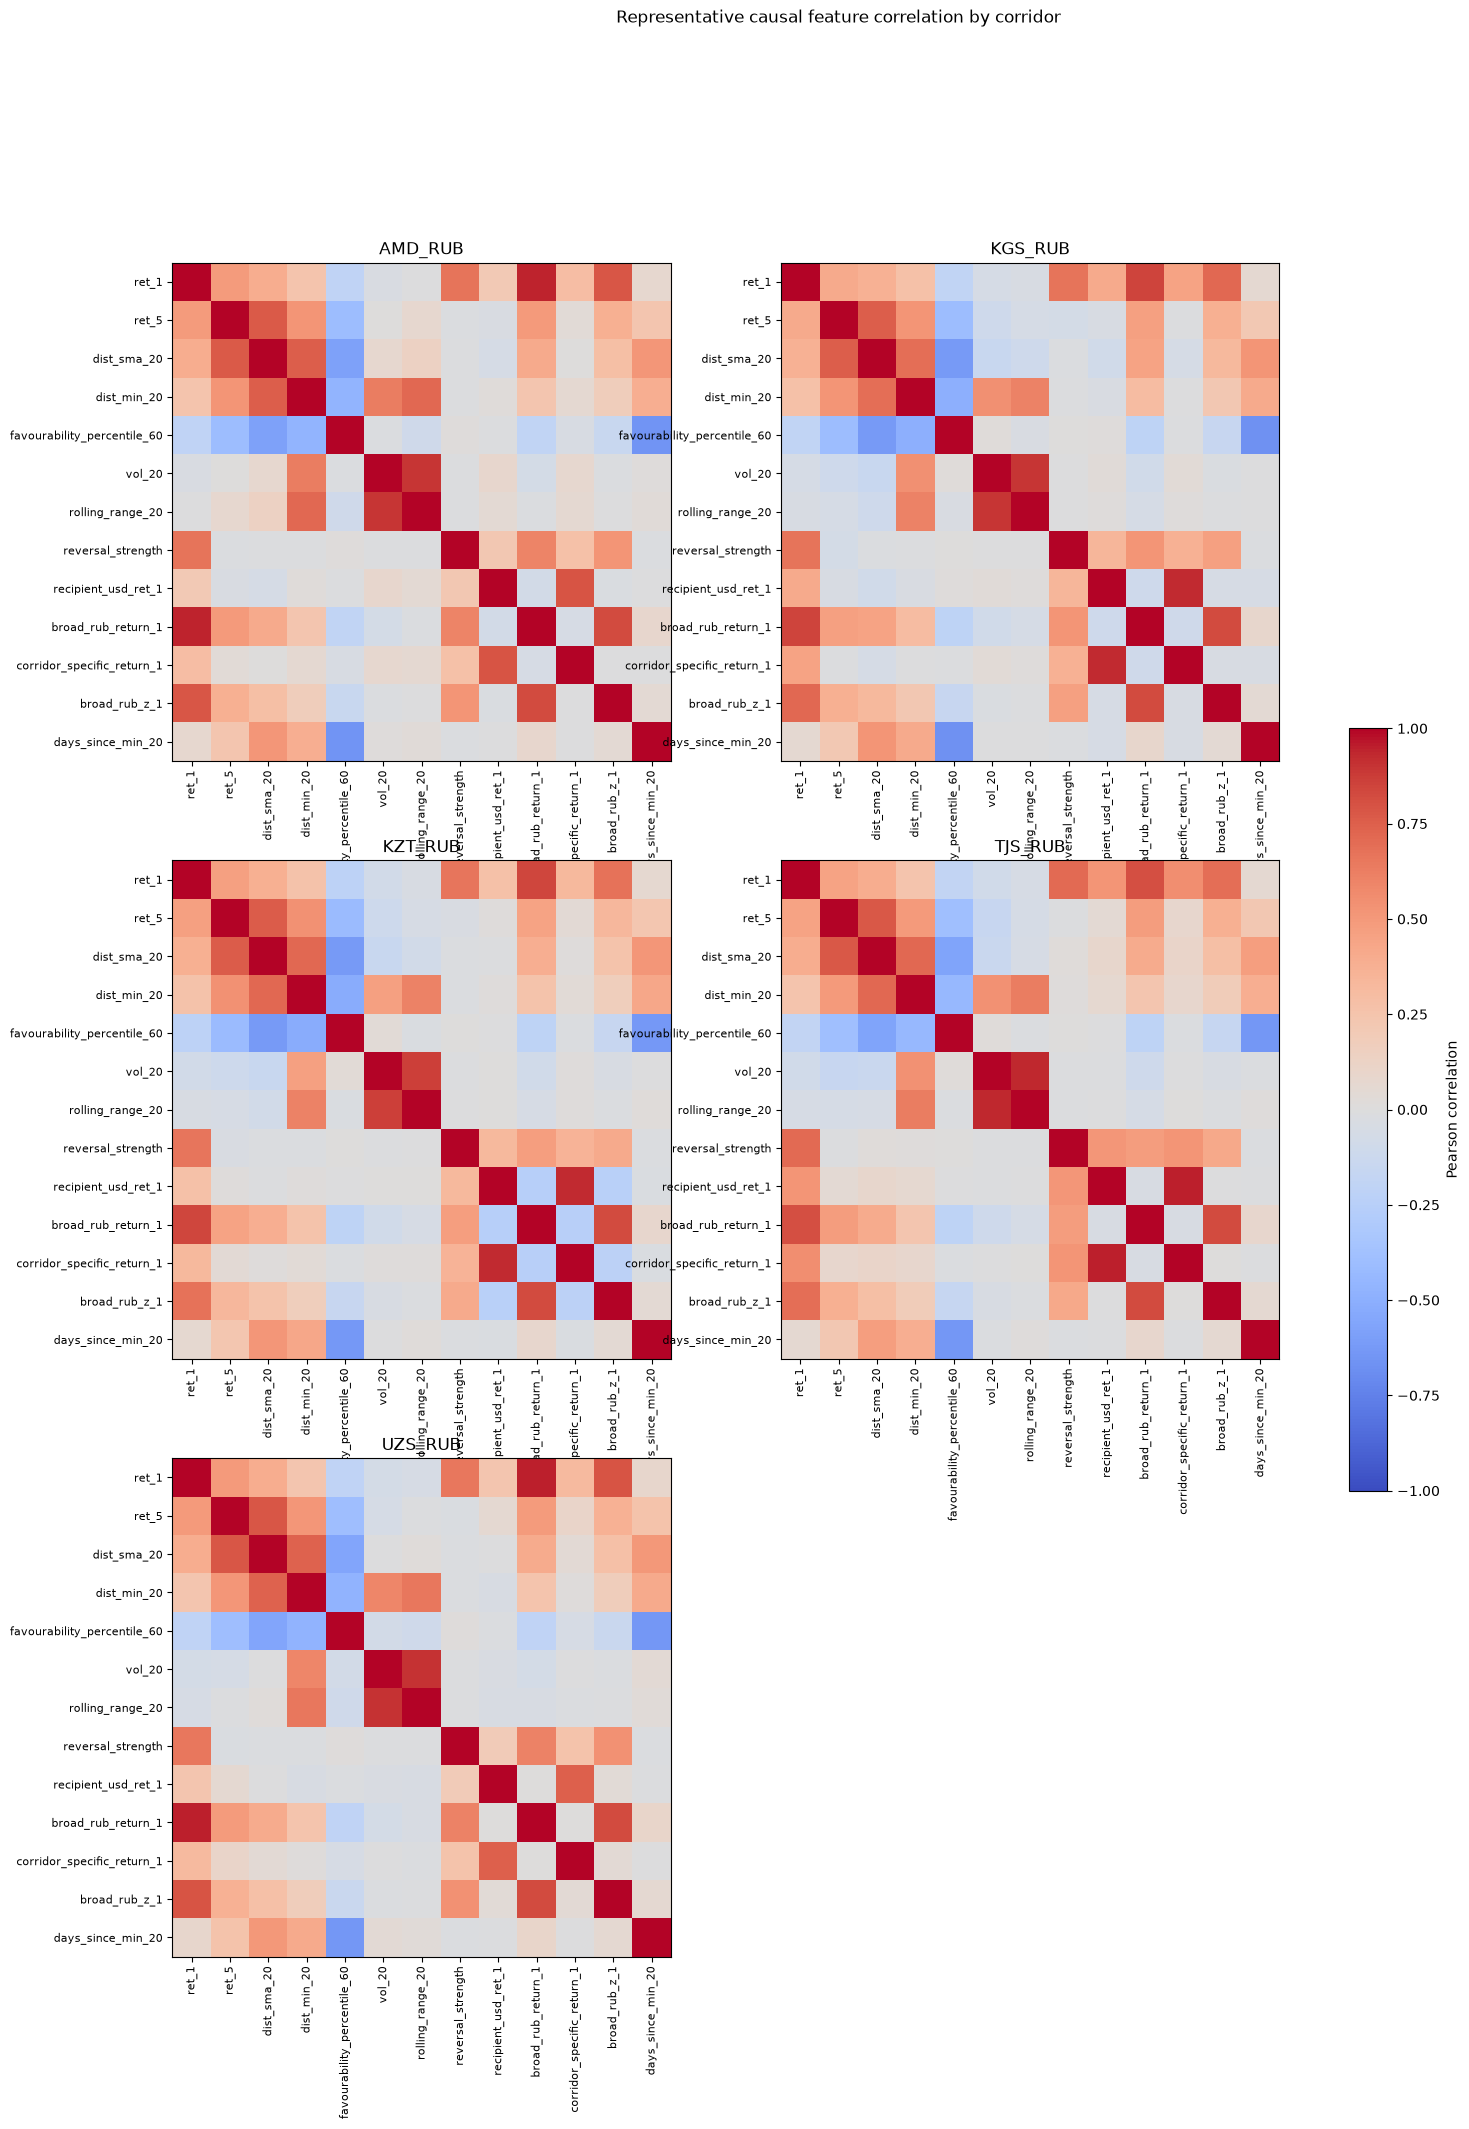

In [7]:
representative_features = [
    'ret_1', 'ret_5', 'dist_sma_20', 'dist_min_20', 'favourability_percentile_60',
    'vol_20', 'rolling_range_20', 'reversal_strength', 'recipient_usd_ret_1',
    'broad_rub_return_1', 'corridor_specific_return_1', 'broad_rub_z_1', 'days_since_min_20',
]
representative_features = [feature for feature in representative_features if feature in correlation_features]
fig, axes = plt.subplots(3, 2, figsize=(18, 22))
axes = axes.ravel()
for axis, (corridor, group) in zip(axes, df.groupby('corridor', sort=True)):
    matrix = group[representative_features].corr(method='pearson')
    image = axis.imshow(matrix, vmin=-1, vmax=1, cmap='coolwarm')
    axis.set_title(corridor)
    axis.set_xticks(range(len(representative_features)), representative_features, rotation=90, fontsize=8)
    axis.set_yticks(range(len(representative_features)), representative_features, fontsize=8)
axes[-1].axis('off')
fig.colorbar(image, ax=axes.tolist(), shrink=0.45, label='Pearson correlation')
fig.suptitle('Representative causal feature correlation by corridor', y=0.995)
plt.show()

## 7. Multicollinearity / VIF

Структурный reduced set исключает forbidden, constants, critical missingness и рекомендованные exact duplicates. VIF считается на complete cases отдельно по каждому corridor для representative continuous subset. Бинарные event flags исключены. `corridor_specific_return_N` не включается одновременно с `ret_N` и `broad_rub_return_N`, потому что это детерминированная линейная комбинация. VIF сам по себе ничего автоматически не удаляет.

In [8]:
duplicate_drop_features = set()
for row in exact_duplicates.itertuples(index=False):
    if row.reason == 'prefer ret_N over mom_N':
        duplicate_drop_features.add(row.recommended_drop)
structural_exclusions = set(constant_features) | set(critical_missing_features) | duplicate_drop_features
structural_reduced_features = [feature for feature in causal_numeric_features if feature not in structural_exclusions]
binary_features = [
    feature for feature in structural_reduced_features
    if set(pd.to_numeric(df[feature], errors='raise').dropna().unique()).issubset({0, 1})
]

requested_vif_subset = [
    'ret_1', 'ret_2', 'ret_3', 'ret_5', 'ret_10', 'ret_20',
    'dist_sma_5', 'dist_sma_20', 'dist_sma_60', 'sma_5_vs_20', 'sma_20_vs_60',
    'dist_min_20', 'dist_min_60', 'dist_min_180', 'dist_max_20', 'dist_max_60', 'dist_max_180',
    'percentile_20', 'percentile_60', 'percentile_180', 'down_streak', 'up_streak',
    'vol_5', 'vol_20', 'vol_60', 'rolling_range_20', 'rolling_range_60',
    'days_since_min_20', 'days_since_min_60', 'reversal_strength',
    'recipient_usd_ret_1', 'recipient_usd_ret_5', 'recipient_usd_ret_10',
    'broad_rub_return_1', 'broad_rub_return_5', 'broad_rub_return_20',
    'broad_rub_z_1', 'broad_rub_z_3', 'broad_rub_z_5',
]
vif_features = [feature for feature in requested_vif_subset if feature in structural_reduced_features and feature not in binary_features]

def vif_for_frame(frame: pd.DataFrame, features: list[str], corridor: str) -> pd.DataFrame:
    complete = frame[features].dropna().astype(float)
    varying = [feature for feature in features if complete[feature].std(ddof=0) > 1e-15]
    standardized = (complete[varying] - complete[varying].mean()) / complete[varying].std(ddof=0)
    matrix = standardized.to_numpy()
    rows = []
    for index, feature in enumerate(varying):
        y = matrix[:, index]
        x = np.delete(matrix, index, axis=1)
        coefficients = np.linalg.lstsq(x, y, rcond=None)[0]
        residual = y - x @ coefficients
        r_squared = 1.0 - float(residual @ residual) / float(y @ y)
        vif = np.inf if r_squared >= 1.0 - 1e-12 else 1.0 / (1.0 - r_squared)
        status = 'severe' if vif > 10 else ('moderate' if vif > 5 else 'acceptable')
        rows.append({'corridor': corridor, 'feature': feature, 'vif': vif, 'status': status, 'complete_rows': len(complete)})
    return pd.DataFrame(rows)

vif_table = pd.concat([
    vif_for_frame(group, vif_features, corridor)
    for corridor, group in df.groupby('corridor', sort=True)
], ignore_index=True).sort_values(['corridor', 'vif'], ascending=[True, False]).reset_index(drop=True)
vif_worst = vif_table.groupby('feature', as_index=False).agg(max_vif=('vif', 'max'))
vif_worst['status'] = np.select(
    [vif_worst['max_vif'] > 10, vif_worst['max_vif'] > 5],
    ['severe', 'moderate'], default='acceptable'
)
display(vif_table)
display(Markdown('### Worst-corridor VIF'))
display(vif_worst.sort_values('max_vif', ascending=False))
print('Structural reduced features:', len(structural_reduced_features))
print('Binary event features excluded from VIF:', binary_features)

,corridor,feature,vif,status,complete_rows
0,AMD_RUB,ret_1,4144.024186,severe,1709
1,AMD_RUB,dist_sma_20,2357.622716,severe,1709
2,AMD_RUB,ret_2,2346.930711,severe,1709
3,AMD_RUB,reversal_strength,1853.815085,severe,1709
4,AMD_RUB,dist_sma_60,1207.937201,severe,1709
5,AMD_RUB,sma_5_vs_20,1104.932861,severe,1709
6,AMD_RUB,rolling_range_20,855.391043,severe,1709
7,AMD_RUB,dist_max_20,535.250023,severe,1709
8,AMD_RUB,dist_min_20,520.116001,severe,1709
9,AMD_RUB,sma_20_vs_60,494.178414,severe,1709


### Worst-corridor VIF

,feature,max_vif,status
24,ret_1,5629.716217,severe
14,dist_sma_20,3735.213243,severe
26,ret_2,3220.676133,severe
30,reversal_strength,2463.658707,severe
31,rolling_range_20,1693.179961,severe
34,sma_5_vs_20,1634.676427,severe
16,dist_sma_60,1551.897474,severe
9,dist_max_20,1304.847673,severe
12,dist_min_20,765.663374,severe
33,sma_20_vs_60,627.409960,severe


Structural reduced features: 89
Binary event features excluded from VIF: ['return_sign_reversal_up', 'near_min_prev_002', 'near_min_reversal_002', 'reversal_2d_002', 'near_min_prev_005', 'near_min_reversal_005', 'reversal_2d_005', 'near_min_prev_010', 'near_min_reversal_010', 'reversal_2d_010']


## 8. PCA — только train-only диагностика

PCA выполняется отдельно по каждому corridor. Validation/test не используются ни для scaler fit, ни для PCA fit. Чтобы не придумывать warm-up значения, используются только полные строки первых 70%. Бинарные event flags исключены из PCA, чтобы редкие события не доминировали после scaling.

,corridor,source_rows,train_rows_before_complete_case,train_complete_rows,train_last_date,input_features,components_80pct,components_90pct,components_95pct
0,AMD_RUB,1889,1322,957,2024-05-23,79,7,12,18
1,KGS_RUB,1889,1322,957,2024-05-23,79,7,12,18
2,KZT_RUB,1889,1322,957,2024-05-23,79,7,11,17
3,TJS_RUB,1889,1322,957,2024-05-23,79,7,12,18
4,UZS_RUB,1889,1322,957,2024-05-23,79,7,12,19


### Explained variance: первые 15 components каждого corridor

,corridor,component,explained_variance_ratio,cumulative_explained_variance
0,AMD_RUB,1,0.266273,0.266273
1,AMD_RUB,2,0.188954,0.455227
2,AMD_RUB,3,0.127321,0.582548
3,AMD_RUB,4,0.088993,0.671541
4,AMD_RUB,5,0.076074,0.747615
5,AMD_RUB,6,0.037697,0.785312
6,AMD_RUB,7,0.032391,0.817703
7,AMD_RUB,8,0.026343,0.844047
8,AMD_RUB,9,0.020986,0.865032
9,AMD_RUB,10,0.016430,0.881462


### Наибольшие absolute loadings первых 3 components

,corridor,component,feature,loading,absolute_loading
0,AMD_RUB,1,dist_sma_60,0.186160,0.186160
1,AMD_RUB,1,dist_sma_20,0.174791,0.174791
2,AMD_RUB,1,percentile_60,0.168497,0.168497
3,AMD_RUB,1,favourability_percentile_60,-0.168497,0.168497
4,AMD_RUB,1,percentile_90,0.162776,0.162776
5,AMD_RUB,1,favourability_percentile_90,-0.162776,0.162776
6,AMD_RUB,1,percentile_365,0.162231,0.162231
7,AMD_RUB,1,favourability_percentile_365,-0.162231,0.162231
8,AMD_RUB,2,sma_60,0.233373,0.233373
9,AMD_RUB,2,sma_20,0.230254,0.230254


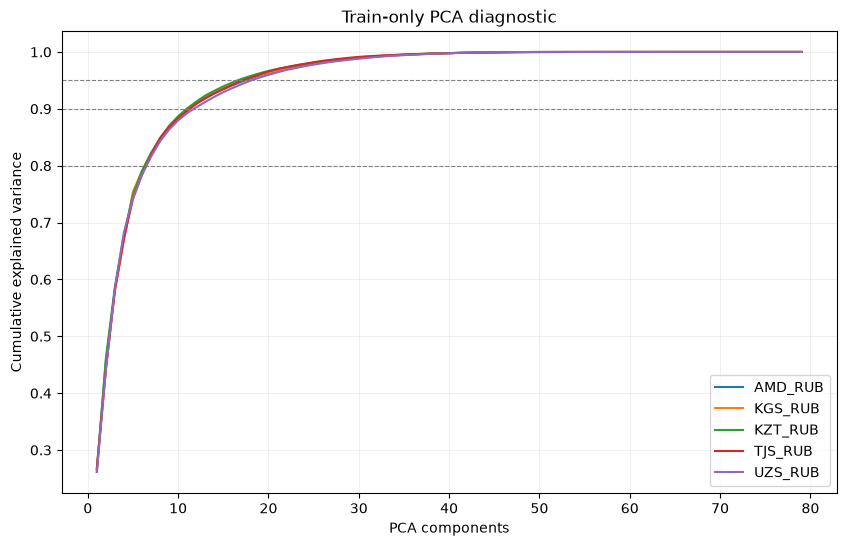

In [9]:
pca_features = [feature for feature in structural_reduced_features if feature not in binary_features]
pca_summary_rows = []
explained_rows = []
loading_rows = []
for corridor, group in df.groupby('corridor', sort=True):
    group = group.sort_values('date').reset_index(drop=True)
    train_size = int(np.floor(len(group) * TRAIN_SHARE))
    train = group.iloc[:train_size]
    train_complete = train[pca_features].dropna().astype(float)
    if len(train_complete) < len(pca_features) + 1:
        raise ValueError(f'Недостаточно complete train rows для PCA {corridor}: {len(train_complete)}')
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_complete)
    pca = PCA()
    pca.fit(train_scaled)
    cumulative = np.cumsum(pca.explained_variance_ratio_)
    thresholds = {
        80: int(np.searchsorted(cumulative, 0.80) + 1),
        90: int(np.searchsorted(cumulative, 0.90) + 1),
        95: int(np.searchsorted(cumulative, 0.95) + 1),
    }
    pca_summary_rows.append({
        'corridor': corridor, 'source_rows': len(group), 'train_rows_before_complete_case': len(train),
        'train_complete_rows': len(train_complete), 'train_last_date': train['date'].max(),
        'input_features': len(pca_features), 'components_80pct': thresholds[80],
        'components_90pct': thresholds[90], 'components_95pct': thresholds[95],
    })
    for component, (ratio, cumulative_ratio) in enumerate(zip(pca.explained_variance_ratio_, cumulative), start=1):
        explained_rows.append({
            'corridor': corridor, 'component': component,
            'explained_variance_ratio': float(ratio), 'cumulative_explained_variance': float(cumulative_ratio),
        })
    for component_index in range(min(3, len(pca.components_))):
        component_loadings = pd.Series(pca.components_[component_index], index=pca_features)
        for feature in component_loadings.abs().nlargest(8).index:
            loading_rows.append({
                'corridor': corridor, 'component': component_index + 1,
                'feature': feature, 'loading': float(component_loadings[feature]),
                'absolute_loading': float(abs(component_loadings[feature])),
            })
pca_summary = pd.DataFrame(pca_summary_rows)
explained_variance = pd.DataFrame(explained_rows)
pca_loadings = pd.DataFrame(loading_rows)
display(pca_summary)
display(Markdown('### Explained variance: первые 15 components каждого corridor'))
display(explained_variance.groupby('corridor', group_keys=False).head(15))
display(Markdown('### Наибольшие absolute loadings первых 3 components'))
display(pca_loadings)

fig, axis = plt.subplots(figsize=(10, 6))
for corridor, group in explained_variance.groupby('corridor', sort=True):
    axis.plot(group['component'], group['cumulative_explained_variance'], label=corridor)
for threshold in (0.80, 0.90, 0.95):
    axis.axhline(threshold, color='grey', linestyle='--', linewidth=0.8)
axis.set(xlabel='PCA components', ylabel='Cumulative explained variance', title='Train-only PCA diagnostic')
axis.legend()
axis.grid(alpha=0.2)
plt.show()

## 9. FEATURE SCREENING SUMMARY и сохранение отчётов

In [10]:
worst_vif_map = vif_worst.set_index('feature')['max_vif'].to_dict()
worst_vif_status_map = vif_worst.set_index('feature')['status'].to_dict()
corr_feature_rows = []
for row in correlation_pairs_090.itertuples(index=False):
    corr_feature_rows.append({'feature': row.feature_1, 'abs_corr': row.abs_pearson_corr, 'ge_098': row.abs_pearson_corr >= 0.98})
    corr_feature_rows.append({'feature': row.feature_2, 'abs_corr': row.abs_pearson_corr, 'ge_098': row.abs_pearson_corr >= 0.98})
corr_feature_audit = pd.DataFrame(corr_feature_rows)
if len(corr_feature_audit):
    corr_feature_summary = corr_feature_audit.groupby('feature').agg(
        max_abs_pearson=('abs_corr', 'max'),
        high_corr_pair_occurrences_090=('abs_corr', 'size'),
        high_corr_pair_occurrences_098=('ge_098', 'sum'),
    )
else:
    corr_feature_summary = pd.DataFrame(columns=['max_abs_pearson', 'high_corr_pair_occurrences_090', 'high_corr_pair_occurrences_098'])

low_or_moderate_vif = sorted(vif_worst.loc[vif_worst['max_vif'] <= 10, 'feature'].tolist())
candidate_reduced_features = sorted(set(low_or_moderate_vif + binary_features))

duplicate_of = {}
for row in exact_duplicates.itertuples(index=False):
    if row.reason == 'prefer ret_N over mom_N':
        duplicate_of[row.recommended_drop] = row.recommended_keep

screening = feature_audit.copy()
screening['exact_duplicate_of'] = screening['feature'].map(duplicate_of).fillna('')
screening['max_abs_pearson_ge_090'] = screening['feature'].map(corr_feature_summary.get('max_abs_pearson', pd.Series(dtype=float)))
screening['high_corr_pair_occurrences_090'] = screening['feature'].map(corr_feature_summary.get('high_corr_pair_occurrences_090', pd.Series(dtype=float))).fillna(0).astype(int)
screening['high_corr_pair_occurrences_098'] = screening['feature'].map(corr_feature_summary.get('high_corr_pair_occurrences_098', pd.Series(dtype=float))).fillna(0).astype(int)
screening['max_vif_representative_subset'] = screening['feature'].map(worst_vif_map)
screening['vif_status'] = screening['feature'].map(worst_vif_status_map).fillna('not_in_vif_subset')
screening['in_structural_reduced_set'] = screening['feature'].isin(structural_reduced_features)
screening['in_candidate_reduced_set'] = screening['feature'].isin(candidate_reduced_features)
screening['recommended_action'] = 'retain for future temporal screening'
screening.loc[screening['role'] == 'TARGET / SERIES', 'recommended_action'] = 'series column; not an exogenous screening decision'
screening.loc[screening['is_constant'], 'recommended_action'] = 'exclude from future feature models: constant on snapshot'
screening.loc[screening['is_critical_missingness'], 'recommended_action'] = 'exclude pending data review: critical missingness'
screening.loc[screening['exact_duplicate_of'] != '', 'recommended_action'] = 'exclude duplicate; prefer ' + screening['exact_duplicate_of']
screening.loc[screening['is_near_constant'] & ~screening['is_constant'], 'recommended_action'] = 'review stability before modeling'

CSV_REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
csv_tmp = CSV_REPORT_PATH.with_suffix(CSV_REPORT_PATH.suffix + '.tmp')
screening.to_csv(csv_tmp, index=False)
csv_tmp.replace(CSV_REPORT_PATH)

corr_counts = correlation_pairs_090.groupby('corridor').size().rename('pairs_ge_090').to_frame()
corr_counts['pairs_ge_098'] = correlation_pairs_098.groupby('corridor').size()
corr_counts = corr_counts.fillna(0).astype(int).reset_index()
vif_counts = vif_table.groupby(['corridor', 'status']).size().unstack(fill_value=0).reset_index()
top_corr_090 = correlation_pairs_090.groupby('corridor', group_keys=False).head(15)
top_vif = vif_table.groupby('corridor', group_keys=False).head(12)

report_lines = [
    '# Model tournament feature screening', '',
    'Этап использует только реальные quote-time features из официальных данных Банка России. Модели и labels не создавались.', '',
    '## Dataset', '', dataset_summary.to_markdown(index=False), '', overview.to_markdown(index=False), '',
    '## Modeling columns', '',
    f'- Identifiers: `{identifier_columns}`.',
    f'- Target / series: `{series_columns}`.',
    f'- Causal features: **{len(causal_features)}**, из них numeric: **{len(causal_numeric_features)}**.',
    f'- Forbidden columns: `{forbidden_columns}`; они исключены из modeling features.', '',
    '## Numeric feature audit', '',
    f'- Near-constant threshold: dominant share ≥ {NEAR_CONSTANT_SHARE:.1%}.',
    f'- Critical missingness threshold: ≥ {CRITICAL_MISSING_SHARE:.0%}.',
    f'- Constants: `{constant_features}`.',
    f'- Near-constants: `{near_constant_features}`.',
    f'- Critical-missingness features: `{critical_missing_features}`.', '',
    feature_audit.to_markdown(index=False), '',
    '## Exact duplicates', '',
    exact_duplicates.to_markdown(index=False), '',
    'Исходный Parquet не менялся. Для будущих feature models рекомендовано сохранять `ret_N` и исключать дублирующий `mom_N`.', '',
    '## Correlation analysis', '', corr_counts.to_markdown(index=False), '',
    'Ниже приведены 15 наиболее сильных Pearson-пар на corridor при `abs(correlation) ≥ 0.90`; полный compact pair table сохранён в выполненных outputs notebook.', '',
    top_corr_090[['corridor', 'feature_1', 'feature_2', 'pearson_corr', 'spearman_corr']].to_markdown(index=False), '',
    '### Все пары с abs(Pearson) ≥ 0.98', '',
    correlation_pairs_098[['corridor', 'feature_1', 'feature_2', 'pearson_corr', 'spearman_corr']].to_markdown(index=False), '',
    '### Highly correlated groups', '', high_correlation_groups.to_markdown(index=False), '',
    '## VIF diagnostic', '',
    'VIF > 10 — severe; 5 < VIF ≤ 10 — moderate. Бинарные flags исключены; VIF не используется для автоматического удаления.', '',
    vif_counts.to_markdown(index=False), '', top_vif.to_markdown(index=False), '',
    '## Train-only PCA diagnostic', '', pca_summary.to_markdown(index=False), '',
    'StandardScaler и PCA fitted отдельно на первых 70% каждого corridor после complete-case отбора. Validation/test не участвовали в fit.', '',
    '### Top loadings первых трёх components', '', pca_loadings.to_markdown(index=False), '',
    '## FEATURE SCREENING SUMMARY', '',
    f'1. Исходное число numeric columns: **{len(numeric_frame.columns)}**; causal numeric features: **{len(causal_numeric_features)}**.',
    f'2. Exact duplicate pairs: **{len(exact_duplicates)}**; рекомендуемые duplicate drops: `{sorted(duplicate_drop_features)}`.',
    f'3. High-correlation pairs: **{len(correlation_pairs_090)}** при `abs(Pearson) ≥ 0.90`, из них **{len(correlation_pairs_098)}** при `≥ 0.98`.',
    f'4. VIF issues: **{int((vif_table.vif > 10).sum())}** severe rows и **{int(((vif_table.vif > 5) & (vif_table.vif <= 10)).sum())}** moderate rows в corridor-level diagnostic.',
    '5. PCA components for 90% variance: `' + str(dict(zip(pca_summary.corridor, pca_summary.components_90pct))) + '`.',
    f'6. Structural reduced set после constants/exact duplicates/critical missingness: **{len(structural_reduced_features)}** features.',
    '7. Предварительный compact candidate set (worst-corridor VIF ≤ 10 на representative subset + binary events): `' + str(candidate_reduced_features) + '`.', '',
    'Этот candidate set является диагностическим shortlist без target-based selection. Перед ARIMAX/ML требуется temporal validation, lag alignment и train-only selection.', '',
    'Для текущих трёх моделей — Naive / ARIMA(rate) / ARIMA(log_return) — feature selection и PCA непосредственно не используются, потому что модели используют собственную историю ряда. Screening предназначен для следующих ARIMAX/ML моделей tournament.', '',
    '**STAGE 1 — DATA & FEATURE SCREENING: PASS**', '',
]
md_tmp = MD_REPORT_PATH.with_suffix(MD_REPORT_PATH.suffix + '.tmp')
md_tmp.write_text('\n'.join(report_lines), encoding='utf-8', newline='\n')
md_tmp.replace(MD_REPORT_PATH)

display(Markdown('## FEATURE SCREENING SUMMARY'))
display(pd.DataFrame([{
    'numeric_columns': len(numeric_frame.columns),
    'causal_numeric_features': len(causal_numeric_features),
    'exact_duplicate_pairs': len(exact_duplicates),
    'high_corr_pairs_ge_090': len(correlation_pairs_090),
    'high_corr_pairs_ge_098': len(correlation_pairs_098),
    'severe_vif_rows': int((vif_table.vif > 10).sum()),
    'candidate_reduced_features': len(candidate_reduced_features),
}]))
print('Candidate reduced feature set:')
print(candidate_reduced_features)
print('Saved:', CSV_REPORT_PATH.relative_to(ROOT))
print('Saved:', MD_REPORT_PATH.relative_to(ROOT))

## FEATURE SCREENING SUMMARY

,numeric_columns,causal_numeric_features,exact_duplicate_pairs,high_corr_pairs_ge_090,high_corr_pairs_ge_098,severe_vif_rows,candidate_reduced_features
0,99,97,10,360,90,123,23


Candidate reduced feature set:
['broad_rub_z_1', 'broad_rub_z_3', 'broad_rub_z_5', 'days_since_min_20', 'days_since_min_60', 'dist_max_180', 'dist_min_180', 'down_streak', 'near_min_prev_002', 'near_min_prev_005', 'near_min_prev_010', 'near_min_reversal_002', 'near_min_reversal_005', 'near_min_reversal_010', 'percentile_180', 'percentile_20', 'recipient_usd_ret_10', 'return_sign_reversal_up', 'reversal_2d_002', 'reversal_2d_005', 'reversal_2d_010', 'up_streak', 'vol_5']
Saved: reports\model_tournament_feature_screening.csv
Saved: reports\model_tournament_feature_screening.md


## 10. Stage status

In [11]:
stage_status = {
    'status': 'PASS',
    'dataset': DATASET_PATH.relative_to(ROOT).as_posix(),
    'rows': len(df),
    'corridors': corridors,
    'numeric_features': len(numeric_frame.columns),
    'causal_numeric_features': len(causal_numeric_features),
    'exact_duplicates': len(exact_duplicates),
    'high_correlation_pairs_ge_090': len(correlation_pairs_090),
    'high_correlation_pairs_ge_098': len(correlation_pairs_098),
    'high_vif_rows': int((vif_table.vif > 10).sum()),
    'high_vif_features': int(vif_table.loc[vif_table.vif > 10, 'feature'].nunique()),
    'pca_components_for_90pct_variance': dict(zip(pca_summary.corridor, pca_summary.components_90pct)),
}
print('STAGE 1 — DATA & FEATURE SCREENING: PASS')
print('Dataset:', stage_status['dataset'])
print('Rows:', stage_status['rows'])
print('Corridors:', stage_status['corridors'])
print('Numeric features:', stage_status['numeric_features'])
print('Exact duplicates:', stage_status['exact_duplicates'])
print('High-correlation pairs:', stage_status['high_correlation_pairs_ge_090'])
print('High-VIF features:', stage_status['high_vif_features'])
print('PCA components for 90% variance:', stage_status['pca_components_for_90pct_variance'])
print('Models trained: 0')

STAGE 1 — DATA & FEATURE SCREENING: PASS
Dataset: data/features/fx_features_daily.parquet
Rows: 9445
Corridors: ['AMD_RUB', 'KGS_RUB', 'KZT_RUB', 'TJS_RUB', 'UZS_RUB']
Numeric features: 99
Exact duplicates: 10
High-correlation pairs: 360
High-VIF features: 26
PCA components for 90% variance: {'AMD_RUB': 12, 'KGS_RUB': 12, 'KZT_RUB': 11, 'TJS_RUB': 12, 'UZS_RUB': 12}
Models trained: 0


# STAGE 2 — TIME SERIES DIAGNOSTICS

Диагностика `rate`, первой разности и `log_ret_1`; ADF/KPSS, ACF/PACF и единый chronological split. На этом этапе model tournament не выполняется.

Вычисления реализованы в `src/time_series_diagnostics.py`; все таблицы, графики и интерпретации ниже являются сохранённым output этой исполняемой ячейки.

# STAGE 2 — TIME SERIES DIAGNOSTICS

Model tournament на этом этапе не выполняется.

## 1. Series и проверка формулы log return

Максимальная абсолютная ошибка: `0.000e+00`.

,date,corridor,rate,expected_log_ret_1,log_ret_1,log_ret_abs_error
1055,2023-04-22,AMD_RUB,0.210304,-0.002294,-0.002294,0.0
1186,2023-10-28,AMD_RUB,0.231567,-0.003862,-0.003862,0.0
1744,2026-02-06,AMD_RUB,0.202514,-0.004002,-0.004002,0.0
2392,2021-01-29,KGS_RUB,0.898336,0.015266,0.015266,0.0
2827,2022-10-28,KGS_RUB,0.739878,-0.003678,-0.003678,0.0
3225,2024-06-14,KGS_RUB,1.012510,-0.010649,-0.010649,0.0
3787,2019-01-23,KZT_RUB,0.175626,0.002411,0.002411,0.0
3812,2019-02-27,KZT_RUB,0.173465,-0.000594,-0.000594,0.0
5630,2026-07-15,KZT_RUB,0.162418,-0.015045,-0.015045,0.0
6032,2020-07-10,TJS_RUB,6.876550,-0.005036,-0.005036,0.0


Все diagnostics, влияющие на выбор `d` и будущих границ `p/q`, рассчитываются только на TRAIN. Validation и TEST для этого не читаются.

## 2. Visual diagnostics

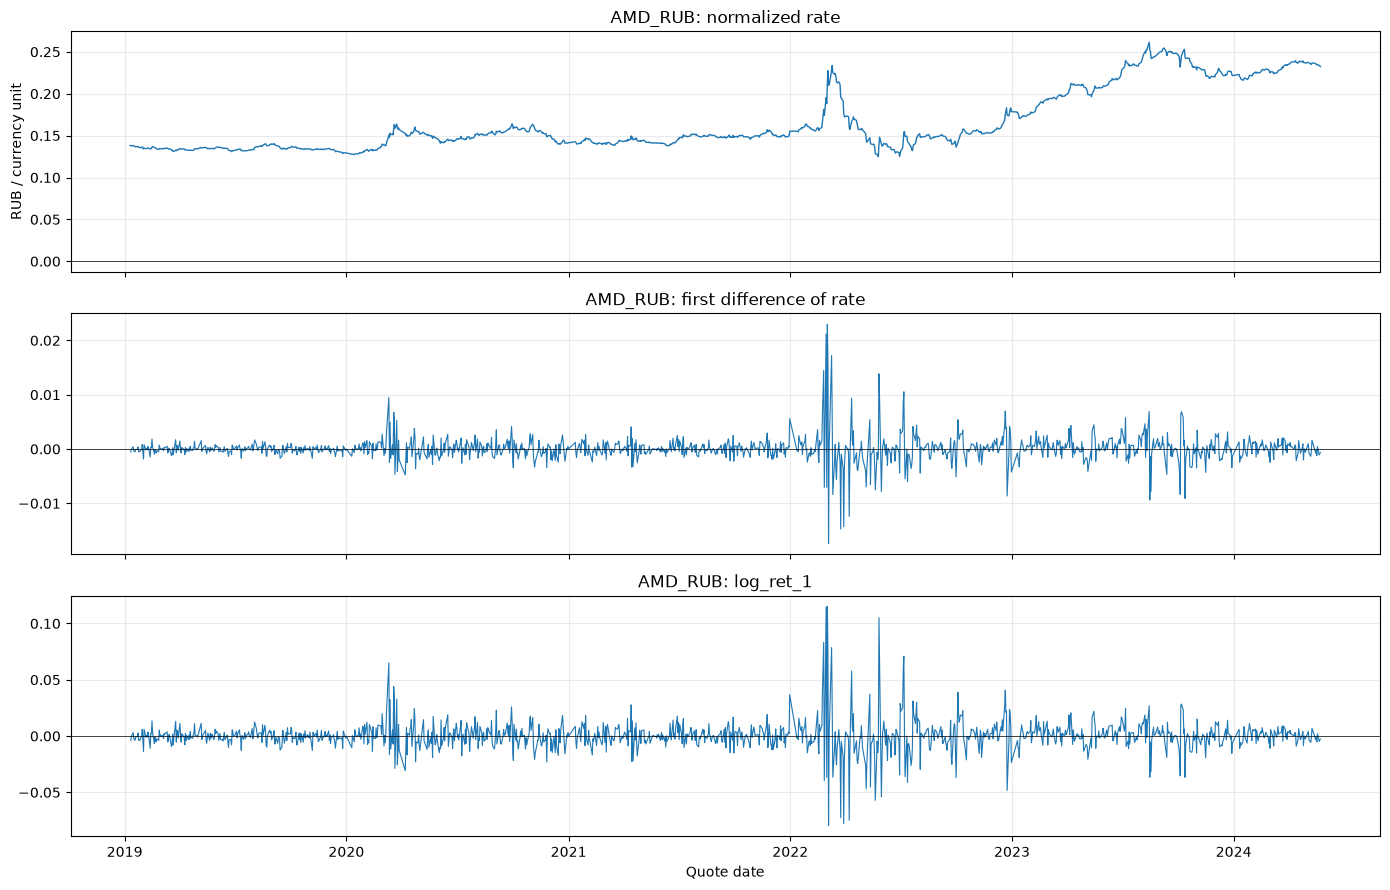

**AMD_RUB.** `rate` изменился между краями выборки на `67.9%`; это описание истории, не прогноз. `diff_rate` колеблется около нуля (std `0.00230815`), но имеет всплески. `log_ret_1` нормирует масштаб (std `0.0131821`). Вывод о стационарности делается ниже по ADF/KPSS, а не только по графику.

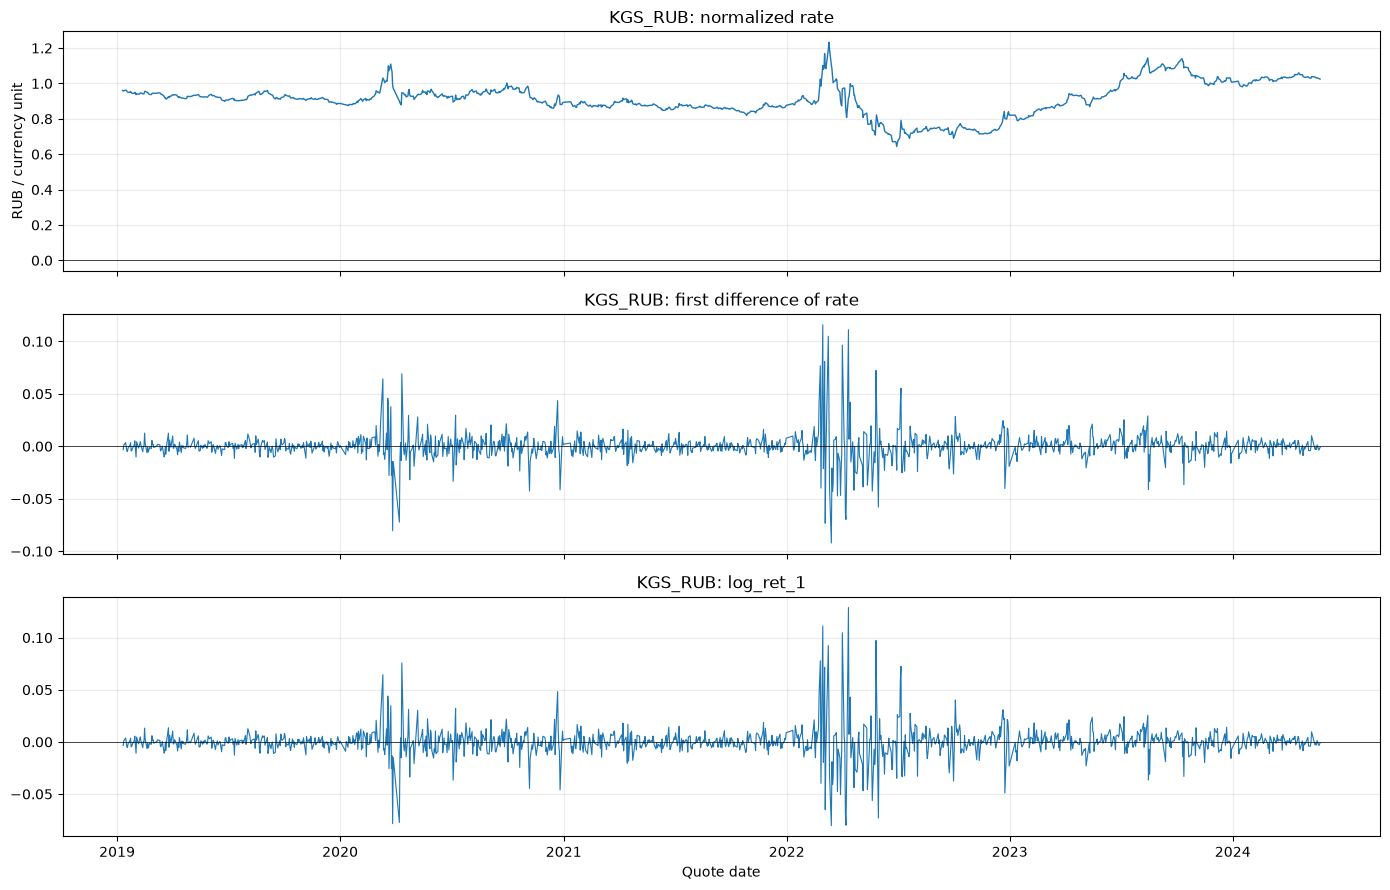

**KGS_RUB.** `rate` изменился между краями выборки на `6.7%`; это описание истории, не прогноз. `diff_rate` колеблется около нуля (std `0.0131989`), но имеет всплески. `log_ret_1` нормирует масштаб (std `0.0142029`). Вывод о стационарности делается ниже по ADF/KPSS, а не только по графику.

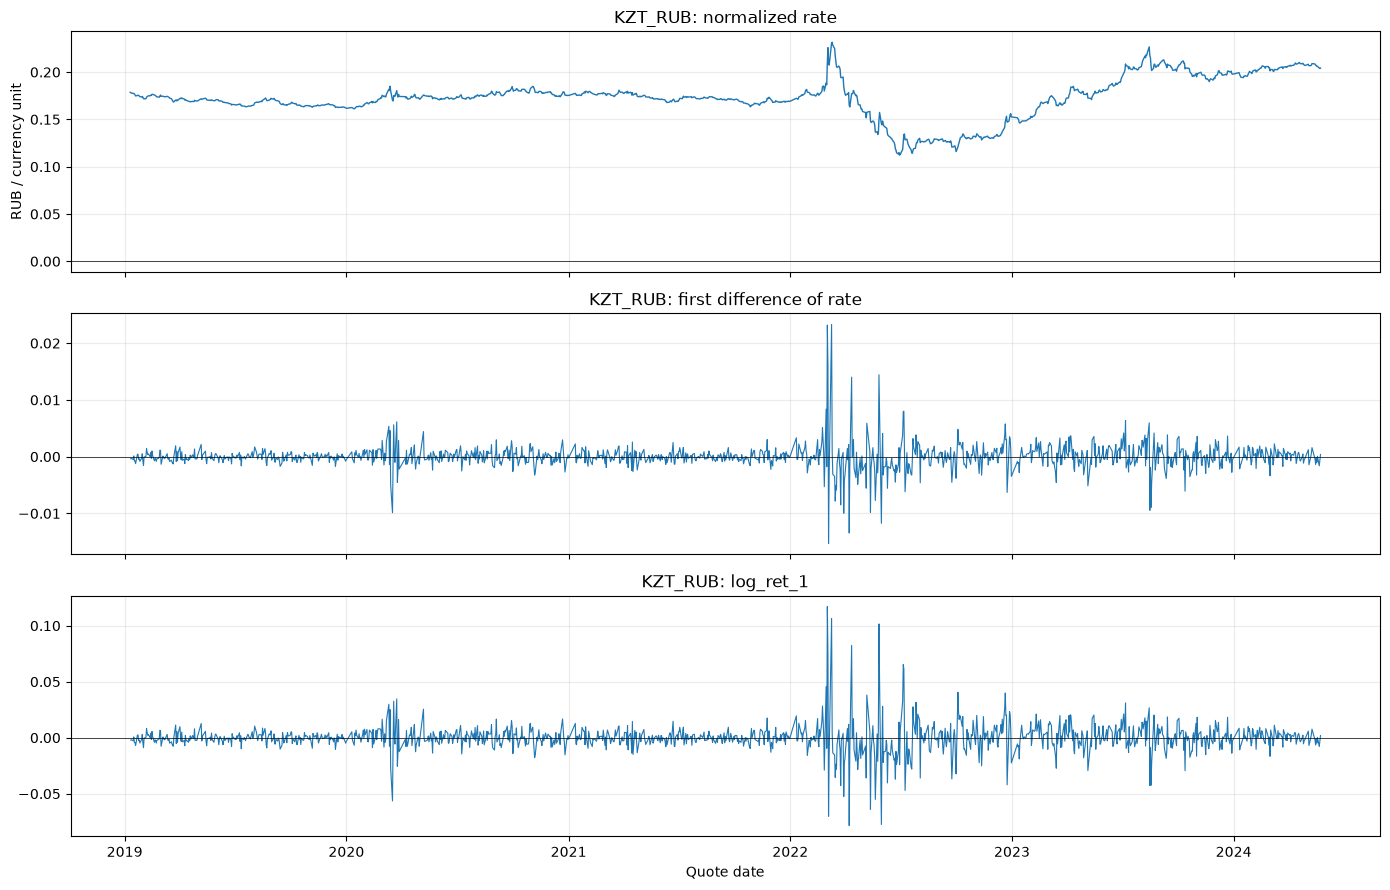

**KZT_RUB.** `rate` изменился между краями выборки на `14.3%`; это описание истории, не прогноз. `diff_rate` колеблется около нуля (std `0.0021317`), но имеет всплески. `log_ret_1` нормирует масштаб (std `0.0123002`). Вывод о стационарности делается ниже по ADF/KPSS, а не только по графику.

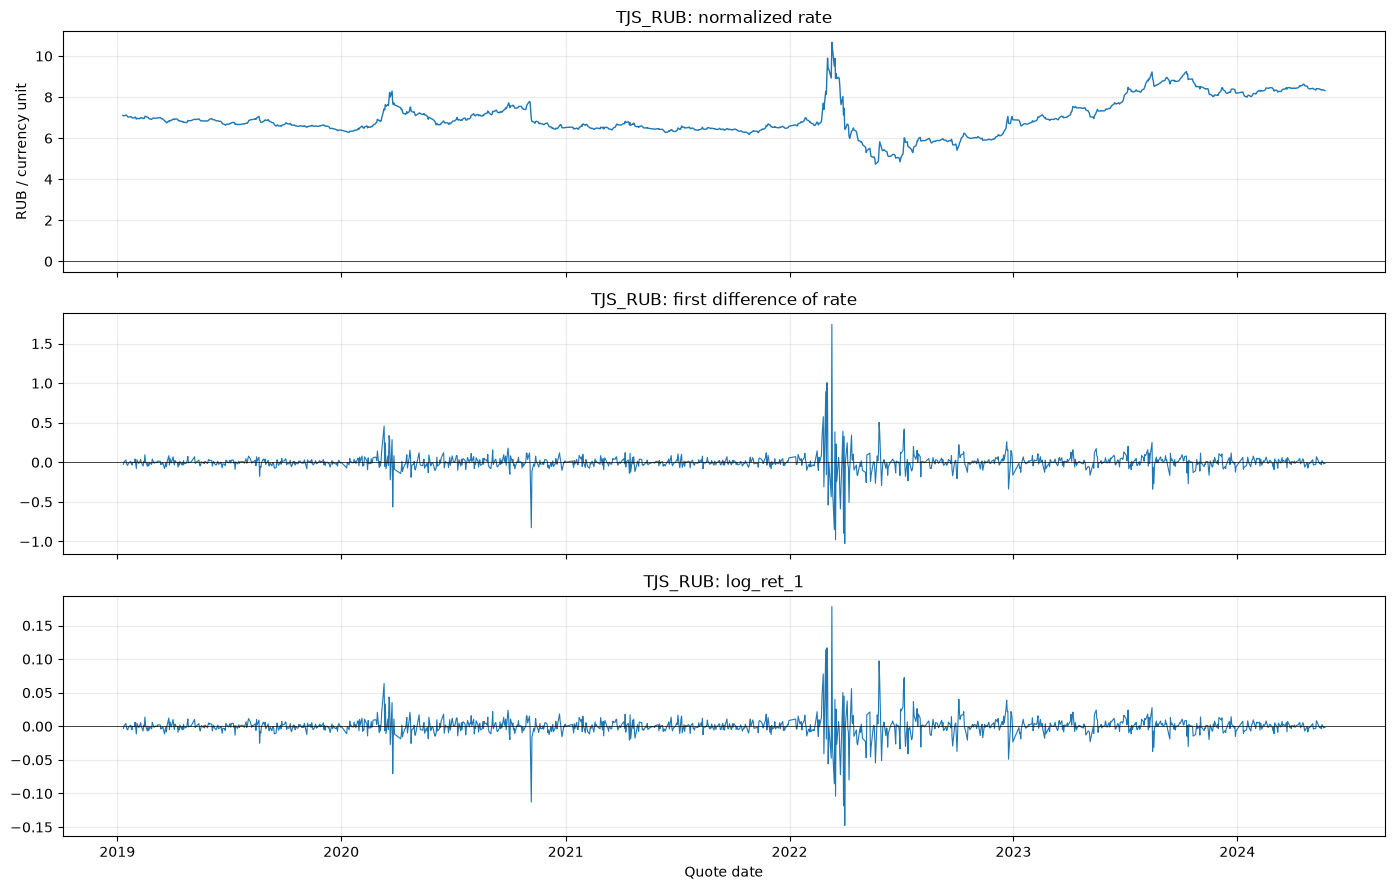

**TJS_RUB.** `rate` изменился между краями выборки на `17.0%`; это описание истории, не прогноз. `diff_rate` колеблется около нуля (std `0.118265`), но имеет всплески. `log_ret_1` нормирует масштаб (std `0.0154485`). Вывод о стационарности делается ниже по ADF/KPSS, а не только по графику.

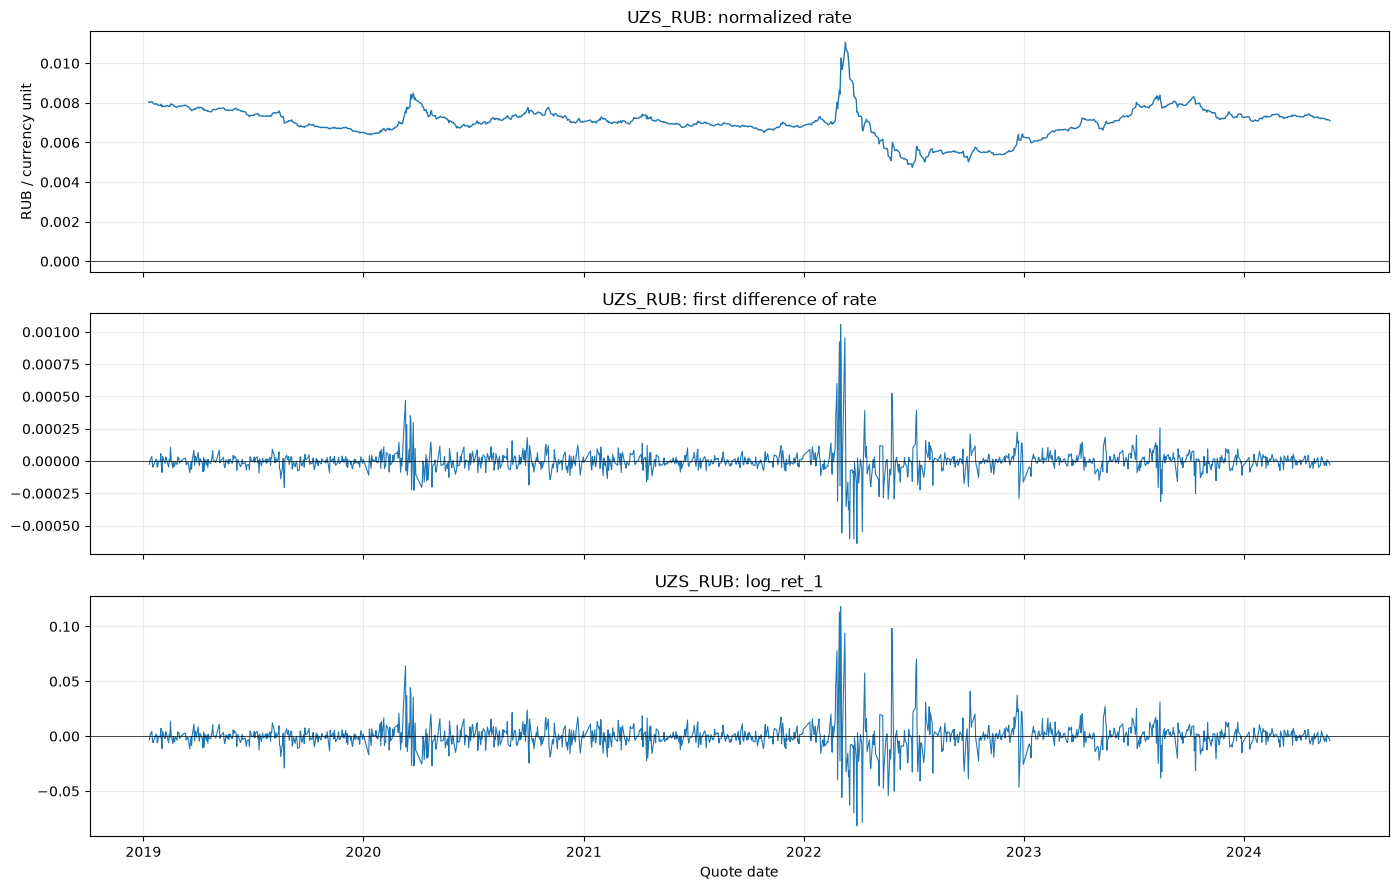

**UZS_RUB.** `rate` изменился между краями выборки на `-11.8%`; это описание истории, не прогноз. `diff_rate` колеблется около нуля (std `9.83869e-05`), но имеет всплески. `log_ret_1` нормирует масштаб (std `0.0131473`). Вывод о стационарности делается ниже по ADF/KPSS, а не только по графику.

## 3. Rolling statistics: 20 и 60 quote observations

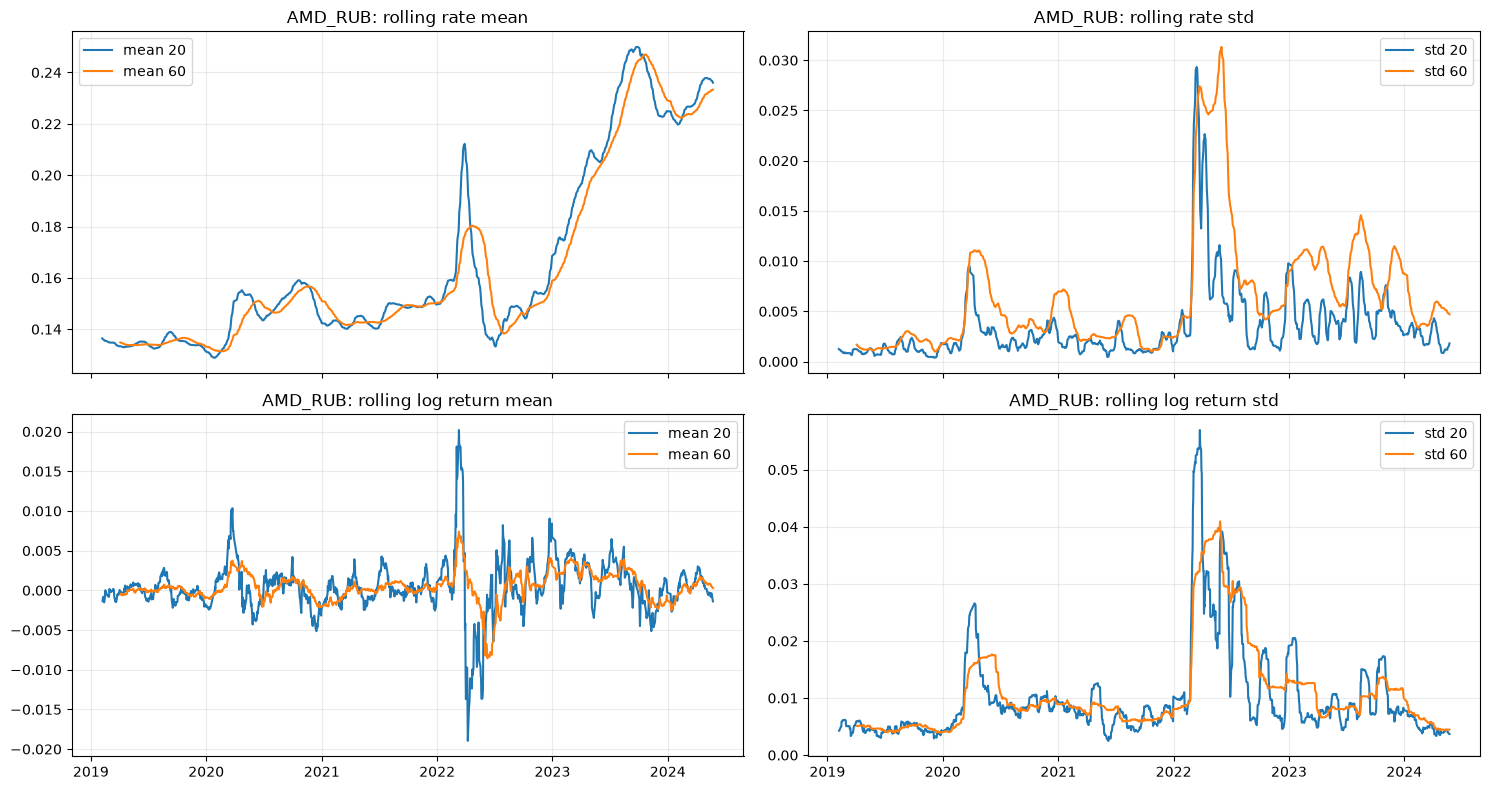

**AMD_RUB.** Rolling mean уровня и rolling variance меняются во времени. Для окна 20 отношение max/min rolling std равно `76.50` для rate и `22.76` для log returns. Это диагностика меняющейся волатильности, не forecast conclusion.

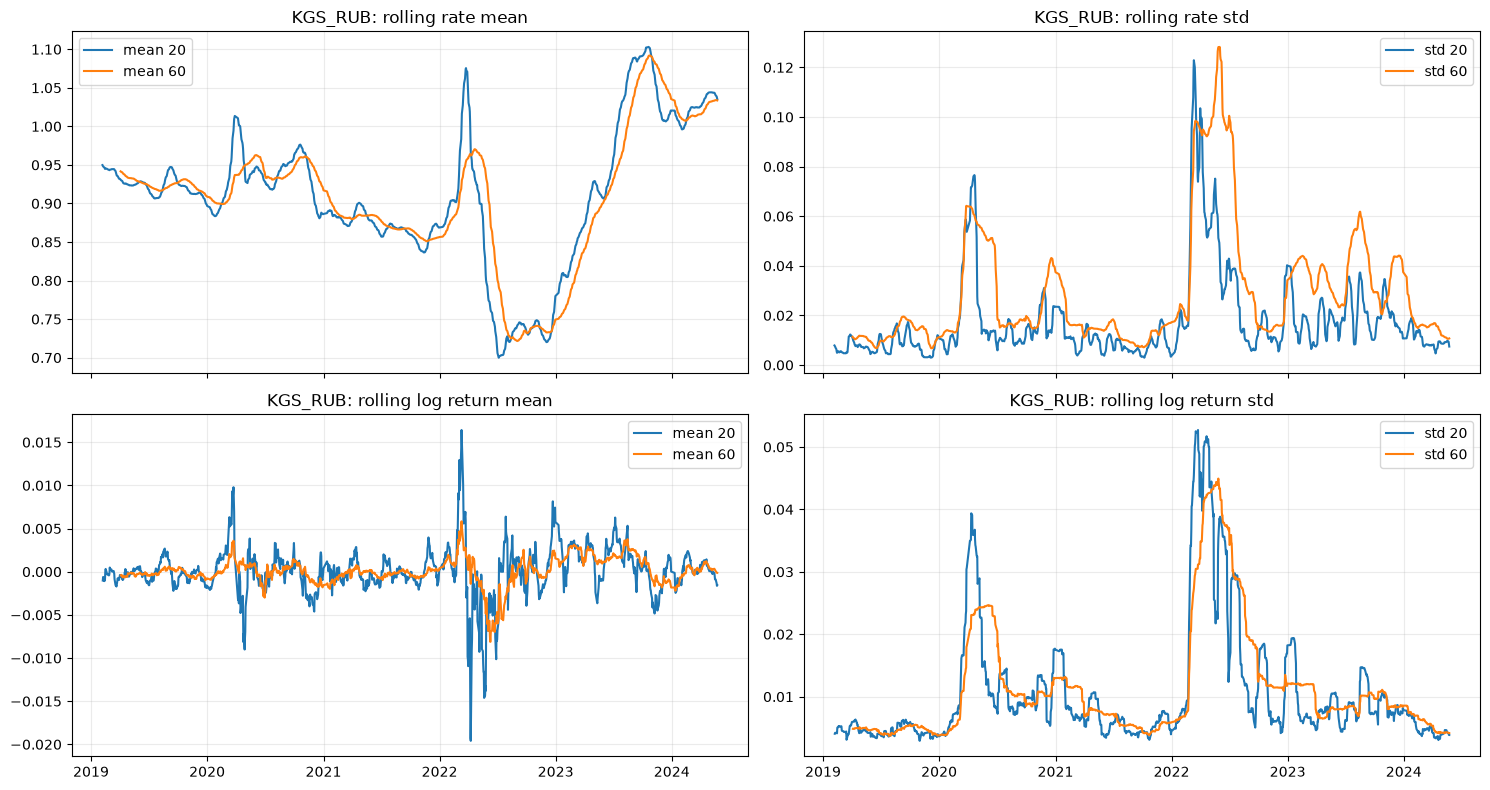

**KGS_RUB.** Rolling mean уровня и rolling variance меняются во времени. Для окна 20 отношение max/min rolling std равно `41.73` для rate и `18.02` для log returns. Это диагностика меняющейся волатильности, не forecast conclusion.

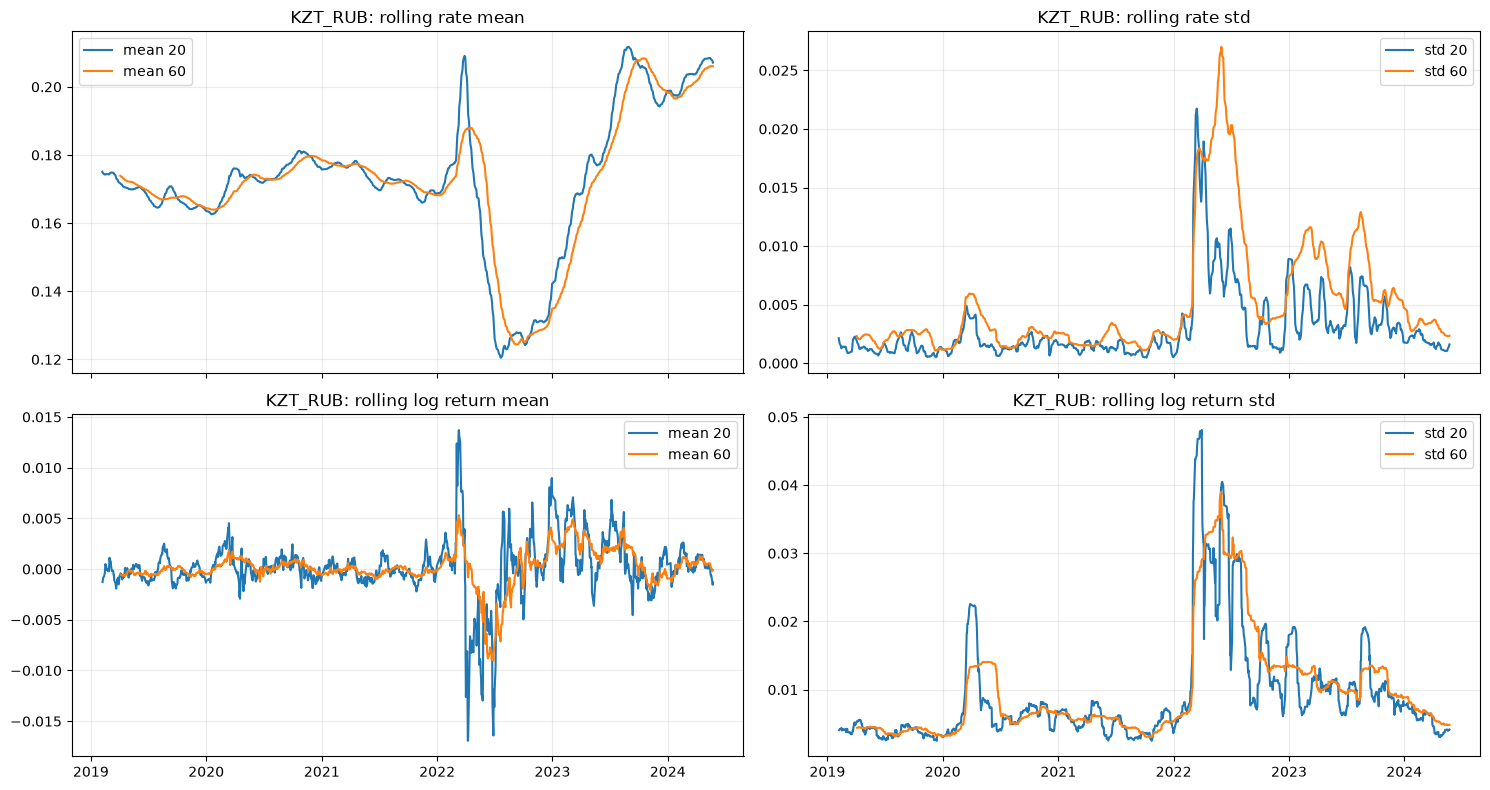

**KZT_RUB.** Rolling mean уровня и rolling variance меняются во времени. Для окна 20 отношение max/min rolling std равно `46.27` для rate и `19.33` для log returns. Это диагностика меняющейся волатильности, не forecast conclusion.

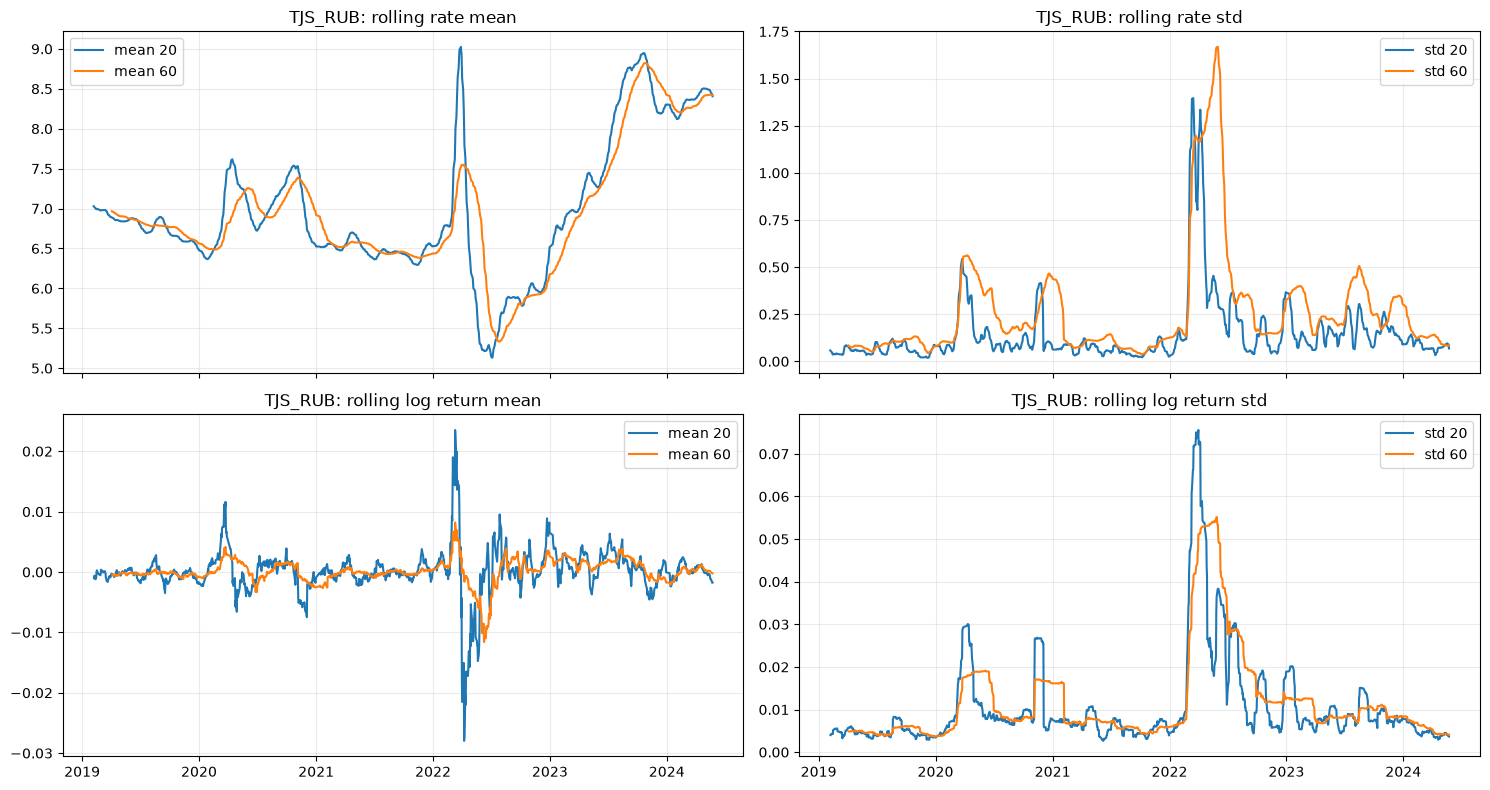

**TJS_RUB.** Rolling mean уровня и rolling variance меняются во времени. Для окна 20 отношение max/min rolling std равно `72.01` для rate и `28.51` для log returns. Это диагностика меняющейся волатильности, не forecast conclusion.

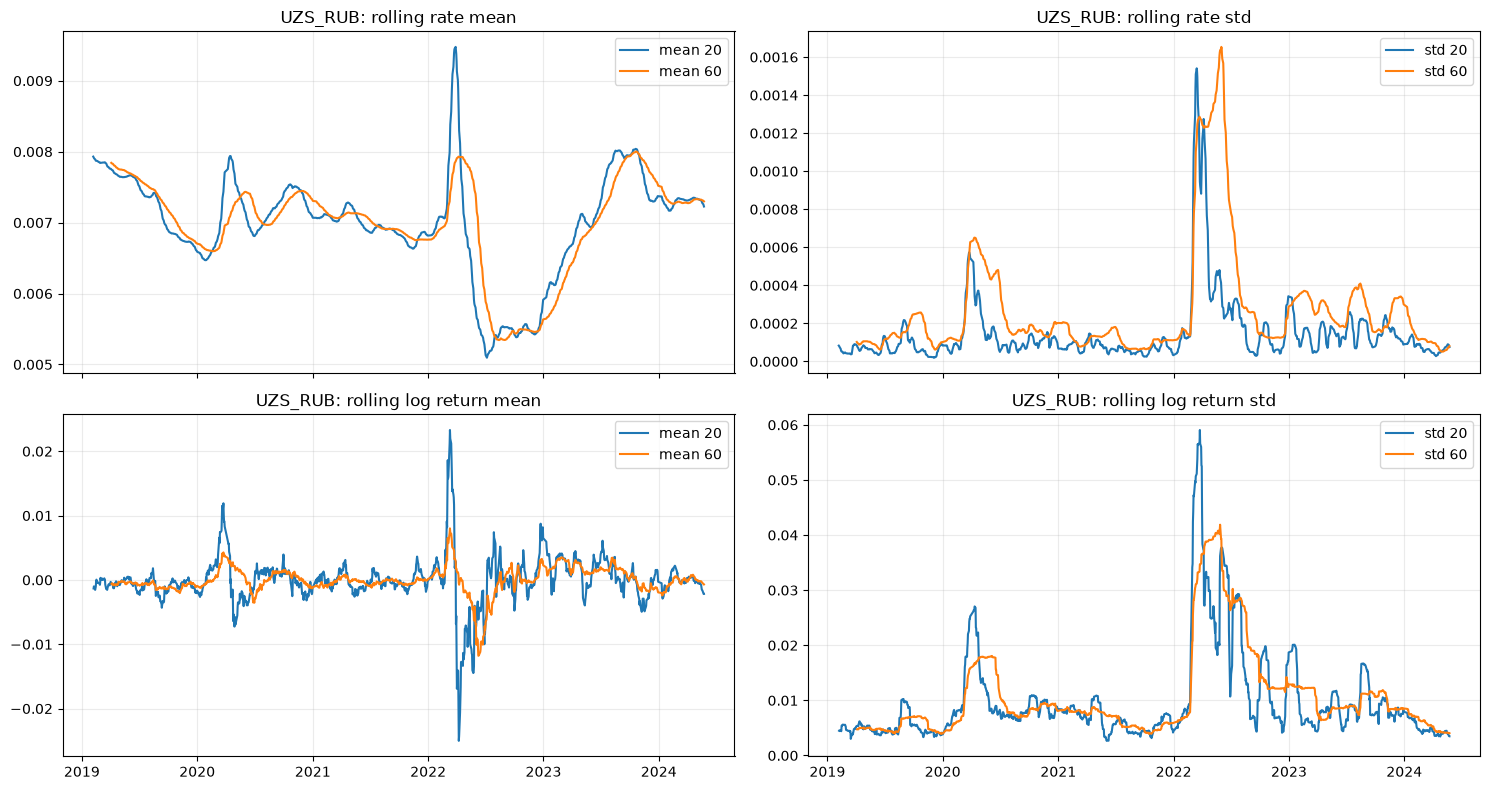

**UZS_RUB.** Rolling mean уровня и rolling variance меняются во времени. Для окна 20 отношение max/min rolling std равно `78.69` для rate и `22.24` для log returns. Это диагностика меняющейся волатильности, не forecast conclusion.

## 4–6. ADF, KPSS и differencing d

ADF: H0 = unit root. KPSS: H0 = stationarity. При `p < 0.05` соответствующая H0 отвергается. Тесты — complementary evidence; они не доказывают стационарность.

,corridor,series,adf_statistic,adf_p,adf_used_lags,adf_n_obs,kpss_statistic,kpss_p,kpss_used_lags,kpss_warning,diagnostic_conclusion
0,AMD_RUB,rate,-0.614121,8.677591e-01,23,1298,4.246981,0.010000,21,The test statistic is outside of the range of ...,evidence consistent with non-stationarity
1,AMD_RUB,diff_rate,-8.334997,3.290572e-13,22,1298,0.082864,0.100000,10,The test statistic is outside of the range of ...,evidence consistent with stationarity
2,AMD_RUB,log_return,-8.882418,1.307095e-14,19,1301,0.072264,0.100000,9,The test statistic is outside of the range of ...,evidence consistent with stationarity
3,KGS_RUB,rate,-1.577425,4.949231e-01,21,1300,0.702625,0.013307,21,kpss currently returns a plain tuple whose len...,evidence consistent with non-stationarity
4,KGS_RUB,diff_rate,-9.090716,3.831012e-15,23,1297,0.069042,0.100000,12,The test statistic is outside of the range of ...,evidence consistent with stationarity
5,KGS_RUB,log_return,-12.324138,6.648014e-23,13,1307,0.080692,0.100000,14,The test statistic is outside of the range of ...,evidence consistent with stationarity
6,KZT_RUB,rate,-1.435723,5.650352e-01,23,1298,0.737619,0.010126,21,kpss currently returns a plain tuple whose len...,evidence consistent with non-stationarity
7,KZT_RUB,diff_rate,-7.854853,5.477338e-12,22,1298,0.113875,0.100000,6,The test statistic is outside of the range of ...,evidence consistent with stationarity
8,KZT_RUB,log_return,-7.594227,2.484872e-11,22,1298,0.117965,0.100000,6,The test statistic is outside of the range of ...,evidence consistent with stationarity
9,TJS_RUB,rate,-1.925511,3.201569e-01,22,1299,1.457260,0.010000,21,The test statistic is outside of the range of ...,evidence consistent with non-stationarity


Для raw rate рассматриваются только `d=0/1`; основной кандидат при нестационарном уровне и более стационарной первой разности — `ARIMA(p,1,q)`. Для log return основной кандидат — `ARIMA(p,0,q)`. `d>1` без сильного основания не используется.

,corridor,rate_adf_p,rate_kpss_p,diff_rate_adf_p,diff_rate_kpss_p,log_return_adf_p,log_return_kpss_p,recommended_rate_d,recommended_logret_d,rate_conclusion,diff_rate_conclusion,log_return_conclusion
0,AMD_RUB,0.867759,0.010000,3.290572e-13,0.1,1.307095e-14,0.1,1,0,evidence consistent with non-stationarity,evidence consistent with stationarity,evidence consistent with stationarity
1,KGS_RUB,0.494923,0.013307,3.831012e-15,0.1,6.648014e-23,0.1,1,0,evidence consistent with non-stationarity,evidence consistent with stationarity,evidence consistent with stationarity
2,KZT_RUB,0.565035,0.010126,5.477338e-12,0.1,2.484872e-11,0.1,1,0,evidence consistent with non-stationarity,evidence consistent with stationarity,evidence consistent with stationarity
3,TJS_RUB,0.320157,0.010000,7.896985e-15,0.1,5.180861e-17,0.1,1,0,evidence consistent with non-stationarity,evidence consistent with stationarity,evidence consistent with stationarity
4,UZS_RUB,0.067608,0.022953,1.659431e-16,0.1,1.513342e-15,0.1,1,0,evidence consistent with non-stationarity,evidence consistent with stationarity,evidence consistent with stationarity


## 7. ACF/PACF и границы будущего grid search

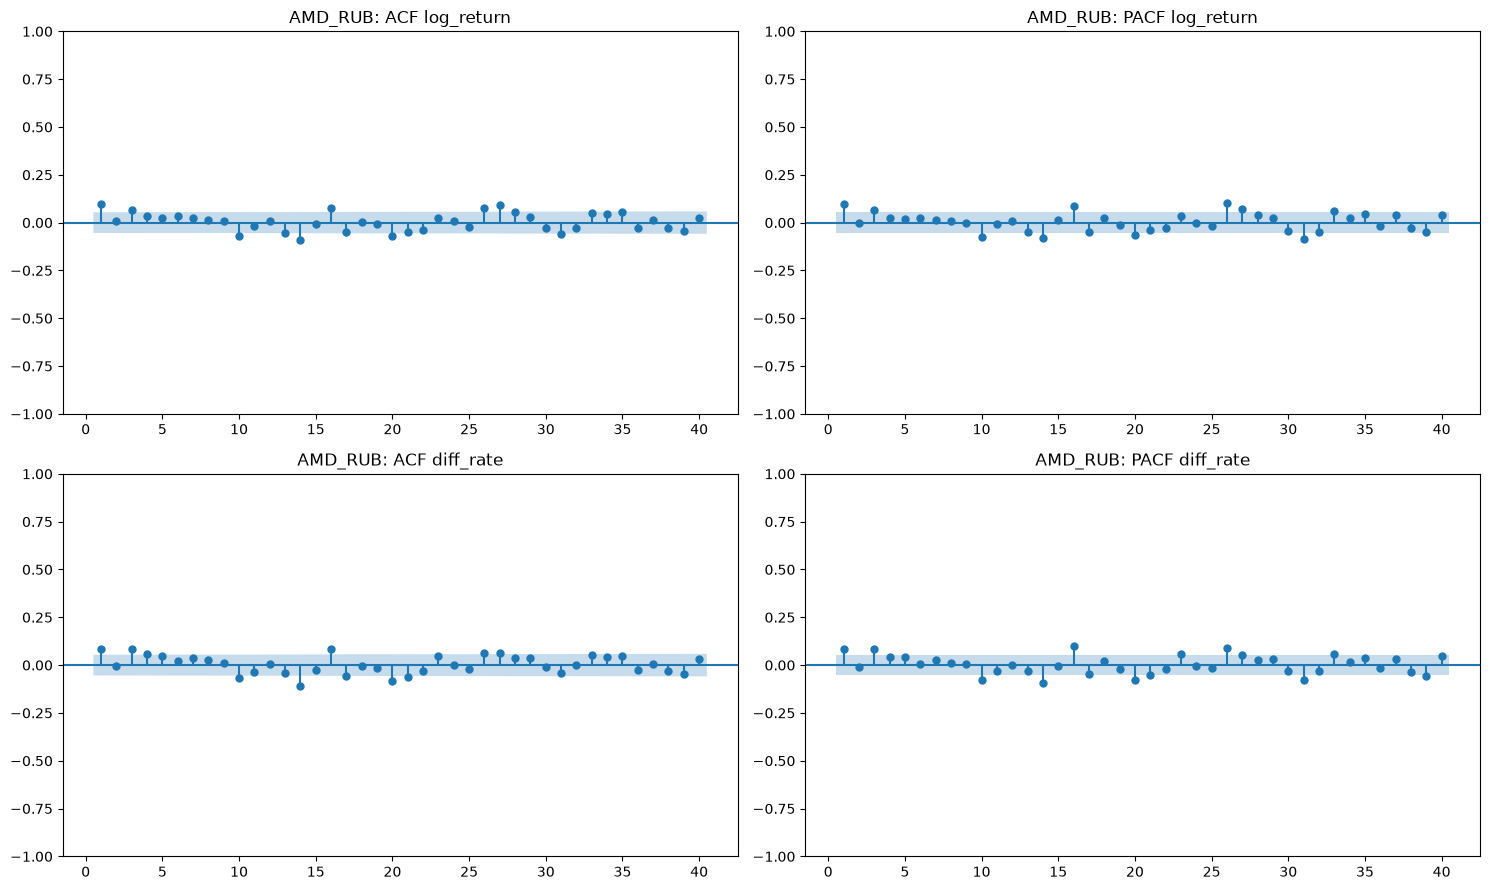

**AMD_RUB.** ACF/PACF ограничивают будущую сетку порядками не выше `5`, но не выбирают `p/q`. Выбор будет сделан только по validation metrics.

,corridor,series,max_lag_plotted,significant_acf_lags_first_10,significant_pacf_lags_first_10,candidate_p_range,candidate_q_range
0,AMD_RUB,log_return,40,"[1, 3, 10]","[1, 3, 10]",0..5,0..5
1,AMD_RUB,diff_rate,40,"[1, 3, 4, 10]","[1, 3, 10]",0..5,0..5


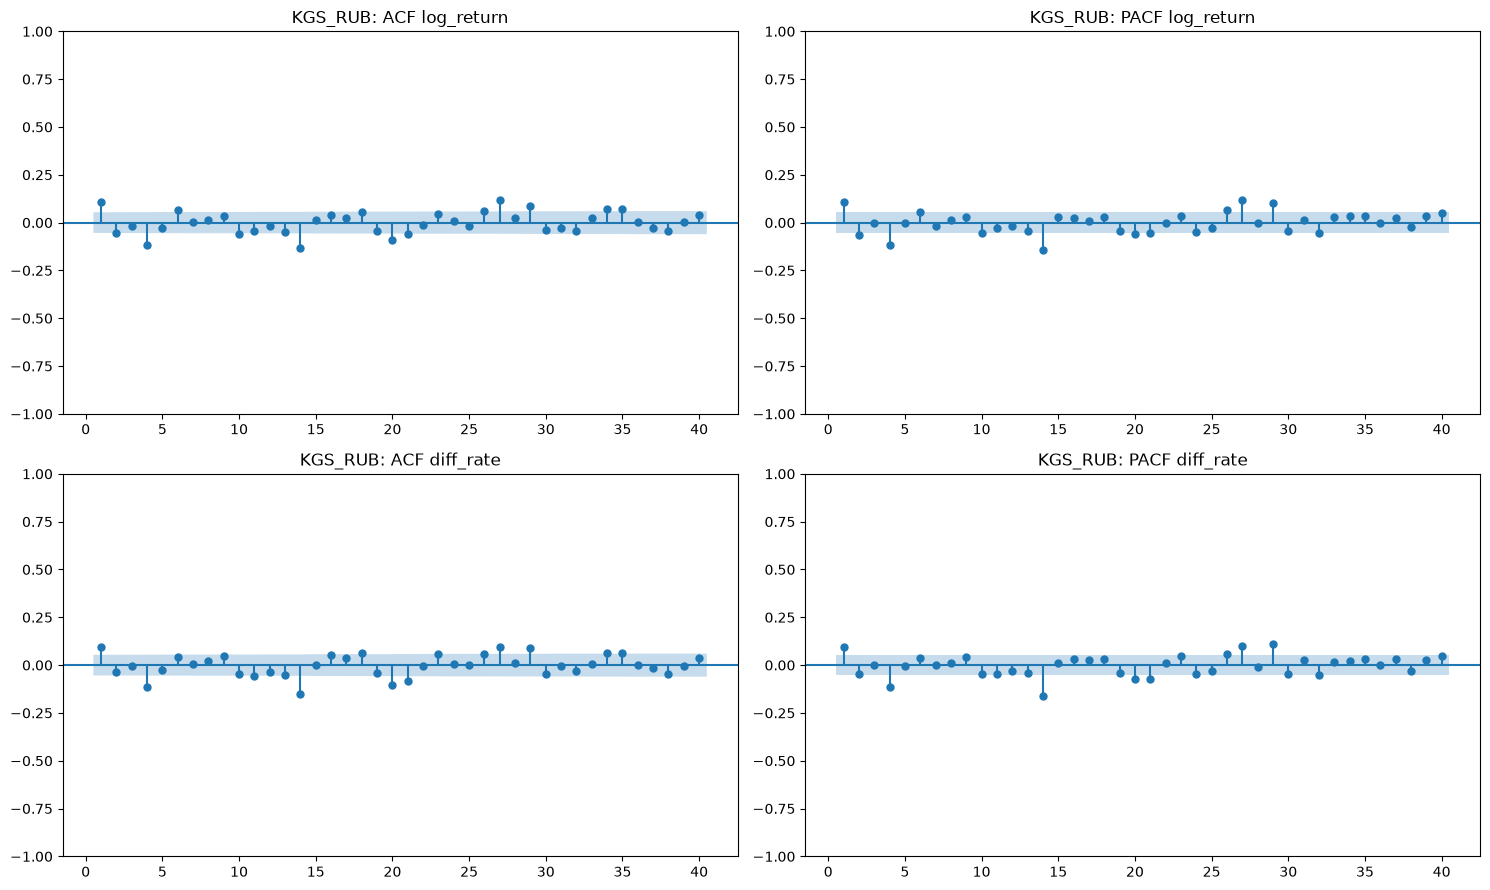

**KGS_RUB.** ACF/PACF ограничивают будущую сетку порядками не выше `5`, но не выбирают `p/q`. Выбор будет сделан только по validation metrics.

,corridor,series,max_lag_plotted,significant_acf_lags_first_10,significant_pacf_lags_first_10,candidate_p_range,candidate_q_range
0,KGS_RUB,log_return,40,"[1, 4, 6, 10]","[1, 2, 4, 6, 10]",0..5,0..5
1,KGS_RUB,diff_rate,40,"[1, 4]","[1, 4]",0..4,0..4


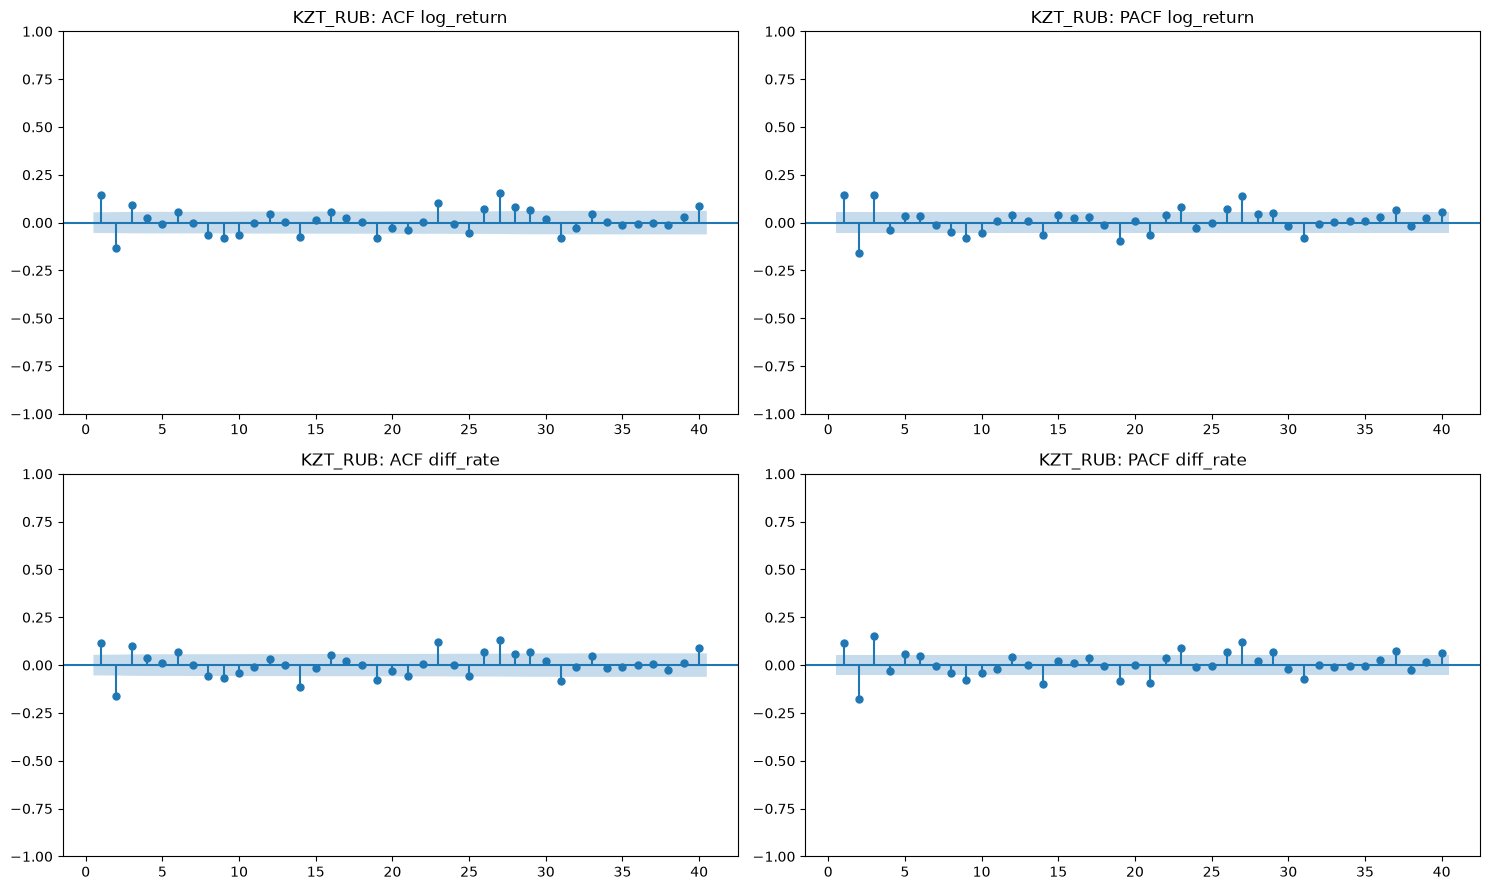

**KZT_RUB.** ACF/PACF ограничивают будущую сетку порядками не выше `5`, но не выбирают `p/q`. Выбор будет сделан только по validation metrics.

,corridor,series,max_lag_plotted,significant_acf_lags_first_10,significant_pacf_lags_first_10,candidate_p_range,candidate_q_range
0,KZT_RUB,log_return,40,"[1, 2, 3, 6, 8, 9, 10]","[1, 2, 3, 9, 10]",0..5,0..5
1,KZT_RUB,diff_rate,40,"[1, 2, 3, 6, 8, 9]","[1, 2, 3, 5, 9]",0..5,0..5


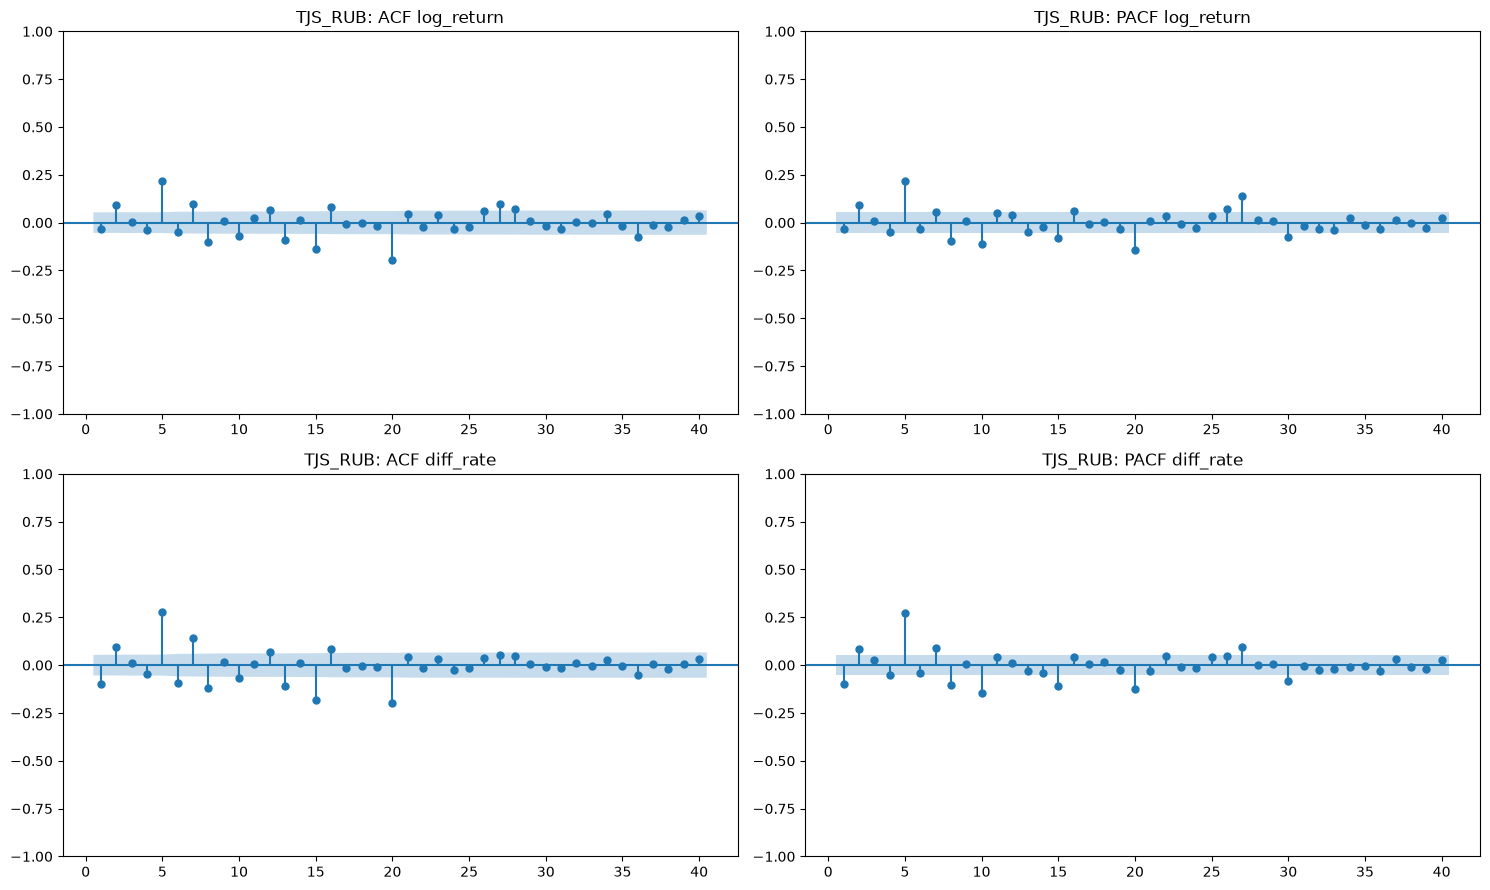

**TJS_RUB.** ACF/PACF ограничивают будущую сетку порядками не выше `5`, но не выбирают `p/q`. Выбор будет сделан только по validation metrics.

,corridor,series,max_lag_plotted,significant_acf_lags_first_10,significant_pacf_lags_first_10,candidate_p_range,candidate_q_range
0,TJS_RUB,log_return,40,"[2, 5, 7, 8, 10]","[2, 5, 7, 8, 10]",0..5,0..5
1,TJS_RUB,diff_rate,40,"[1, 2, 5, 6, 7, 8, 10]","[1, 2, 5, 7, 8, 10]",0..5,0..5


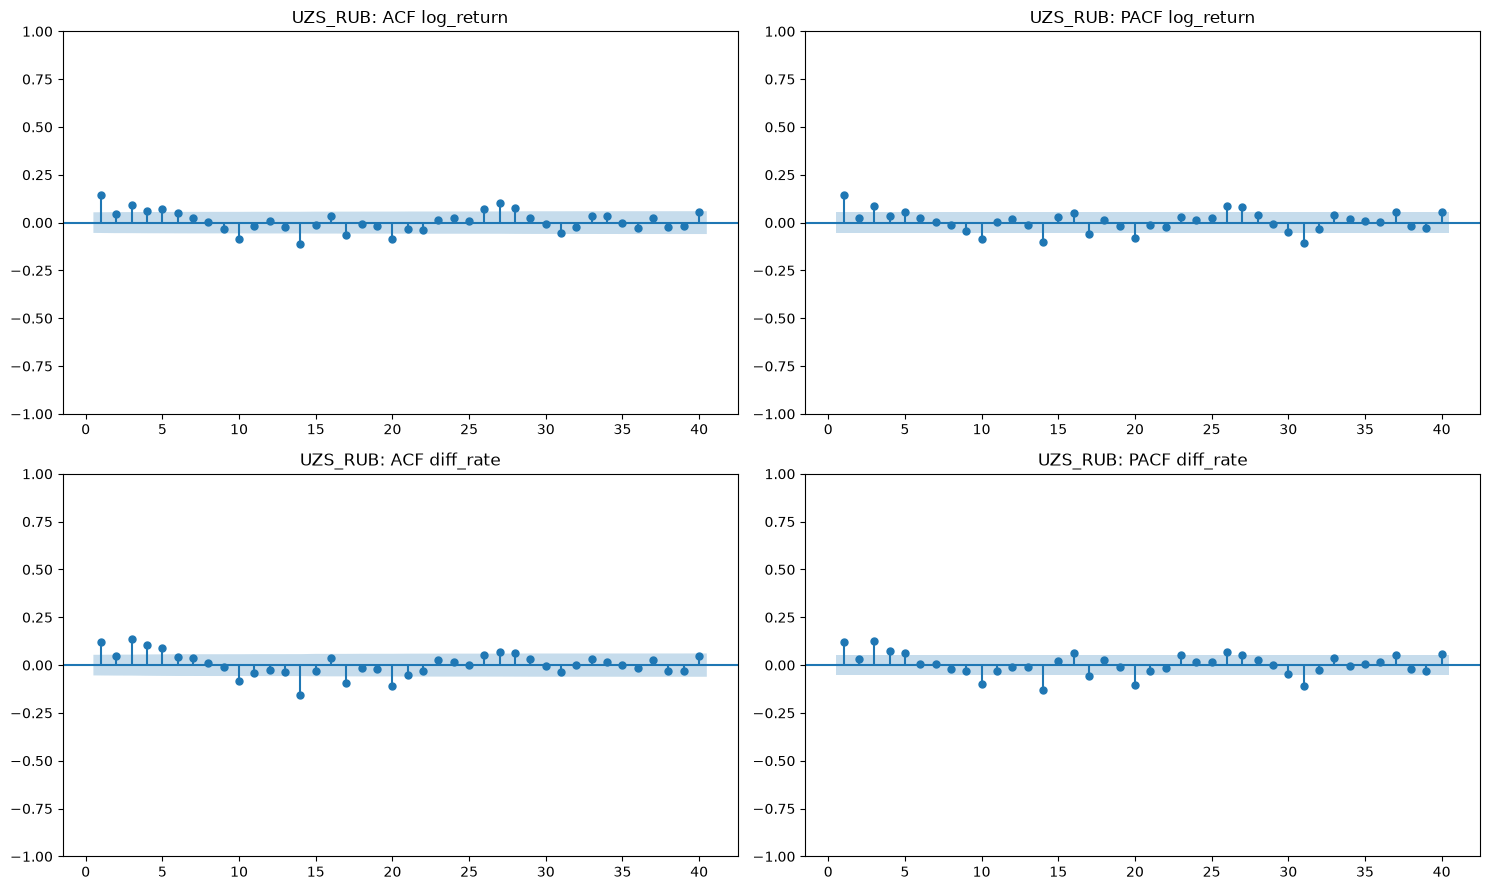

**UZS_RUB.** ACF/PACF ограничивают будущую сетку порядками не выше `5`, но не выбирают `p/q`. Выбор будет сделан только по validation metrics.

,corridor,series,max_lag_plotted,significant_acf_lags_first_10,significant_pacf_lags_first_10,candidate_p_range,candidate_q_range
0,UZS_RUB,log_return,40,"[1, 3, 4, 5, 10]","[1, 3, 5, 10]",0..5,0..5
1,UZS_RUB,diff_rate,40,"[1, 3, 4, 5, 10]","[1, 3, 4, 5, 10]",0..5,0..5


## 8. Forecast horizons и chronological split

Зафиксированы quote-observation horizons `H=[1,3,5,10]`; это не календарные дни. `H=5` — PRIMARY PRODUCT HORIZON, остальные горизонты проверяют более короткое и длинное поведение. Forecast origin допустим только при наличии всех actual observations до `T+10`. Последние 10 строк каждого ряда исключаются только как origins: это right-censoring, а не missing data. Validation targets не пересекаются с test targets.

### Обязательная policy выбора p,d,q

...

**KGS_RUB:** raw rate — evidence consistent with non-stationarity; differenced rate — evidence consistent with stationarity; log return — evidence consistent with stationarity; recommended rate ARIMA `d=1`; recommended log-return ARIMA `d=0`.

**KZT_RUB:** raw rate — evidence consistent with non-stationarity; differenced rate — evidence consistent with stationarity; log return — evidence consistent with stationarity; recommended rate ARIMA `d=1`; recommended log-return ARIMA `d=0`.

**TJS_RUB:** raw rate — evidence consistent with non-stationarity; differenced rate — evidence consistent with stationarity; log return — evidence consistent with stationarity; recommended rate ARIMA `d=1`; recommended log-return ARIMA `d=0`.

**UZS_RUB:** raw rate — evidence consistent with non-stationarity; differenced rate — evidence consistent with stationarity; log return — evidence consistent with stationarity; recommended rate ARIMA `d=1`; recommended log-return ARIMA `d=0`.

Report: reports/time_series_diagnostics.csv
Split report: reports/temporal_split_horizons.csv
Selection policy: reports/model_selection_policy.csv
Models trained: 0
TEST SET IS LOCKED.


In [12]:
from src.time_series_diagnostics import run_stage2

stage2_results = run_stage2(ROOT)

# STAGE 3 — NAIVE BASELINE

Первая модель tournament: leakage-safe Naive Random Walk на зафиксированном Stage 2 test period. ARIMA на этом этапе не обучается.

Реализация находится в `src/naive_baseline.py`; построчные прогнозы, метрики, графики и проверки сохраняются в output следующей ячейки.

# STAGE 3 — NAIVE BASELINE

## 1–2. Model definition и walk-forward

Для каждого origin строится полный путь: `P_hat_(T+1)=...=P_hat_(T+10)=P_T`. Endpoint-метрики считаются на quote-observation horizons `H=[1,3,5,10]`, где `H=5` — PRIMARY PRODUCT HORIZON. Predicted cumulative log return равен 0. Используются только origins, для которых известны все actual values до T+10.

,forecast_origin_date,target_date,corridor,horizon,is_evaluation_horizon,is_primary_horizon,actual_rate,predicted_rate,actual_return,predicted_return
0,2025-07-12,2025-07-15,AMD_RUB,1,True,False,0.204020,0.202874,0.005633,0.0
1,2025-07-15,2025-07-16,AMD_RUB,1,True,False,0.202953,0.204020,-0.005244,0.0
2,2025-07-16,2025-07-17,AMD_RUB,1,True,False,0.203038,0.202953,0.000419,0.0
3,2025-07-17,2025-07-18,AMD_RUB,1,True,False,0.203545,0.203038,0.002494,0.0
4,2025-07-18,2025-07-19,AMD_RUB,1,True,False,0.203818,0.203545,0.001340,0.0
5,2025-07-19,2025-07-22,AMD_RUB,1,True,False,0.204068,0.203818,0.001226,0.0
6,2025-07-22,2025-07-23,AMD_RUB,1,True,False,0.203371,0.204068,-0.003421,0.0
7,2025-07-23,2025-07-24,AMD_RUB,1,True,False,0.204344,0.203371,0.004773,0.0
8,2025-07-24,2025-07-25,AMD_RUB,1,True,False,0.205510,0.204344,0.005690,0.0
9,2025-07-25,2025-07-26,AMD_RUB,1,True,False,0.207201,0.205510,0.008195,0.0


## 3–6. Endpoint, path и future-best metrics

`MAE` и `RMSE` считаются в единицах rate. `normalized_MAE` — дополнительная относительная метрика и не заменяет основные. Для всех моделей используется единое правило направления: прогноз корректен, когда знаки actual и predicted return совпадают, включая случай, когда оба равны нулю. Если predicted return равен 0, а actual return не равен 0, направление считается неверным.

...

,corridor,model,horizon,is_primary_horizon,MAE,RMSE,directional_accuracy,normalized_MAE,Path_MAE_H,Future_Best_MAE_H,Regret_MAE_H,n_forecasts
2,AMD_RUB,NAIVE,5,True,0.003491,0.004413,0.0,0.016625,0.002538,0.002492,0.010045,275
3,AMD_RUB,NAIVE,10,False,0.004907,0.006205,0.0,0.023284,0.003451,0.003455,0.015124,275
6,KGS_RUB,NAIVE,5,True,0.015246,0.019270,0.0,0.016918,0.011020,0.011122,0.010534,275
7,KGS_RUB,NAIVE,10,False,0.021649,0.027256,0.0,0.024018,0.015094,0.015759,0.016133,275
10,KZT_RUB,NAIVE,5,True,0.002901,0.003878,0.0,0.018301,0.002191,0.002124,0.011313,275
11,KZT_RUB,NAIVE,10,False,0.004251,0.005681,0.0,0.026419,0.002928,0.002829,0.016239,275
14,TJS_RUB,NAIVE,5,True,0.145904,0.182237,0.0,0.017319,0.106032,0.105599,0.010582,275
15,TJS_RUB,NAIVE,10,False,0.203219,0.255267,0.0,0.024090,0.144129,0.148644,0.016161,275
18,UZS_RUB,NAIVE,5,True,0.000119,0.000149,0.0,0.018323,0.000089,0.000088,0.011373,275
19,UZS_RUB,NAIVE,10,False,0.000167,0.000209,0.0,0.025514,0.000118,0.000119,0.016753,275


**Primary H=5 macro average по пяти коридорам:**

,MAE,RMSE,directional_accuracy,normalized_MAE
macro_average,0.033532,0.041989,0.0,0.017497


Weighted normalized MAE: `0.01749729`. При одинаковом числе прогнозов он совпадает с macro normalized MAE.

## 7. Primary H=5 actual rate vs Naive prediction

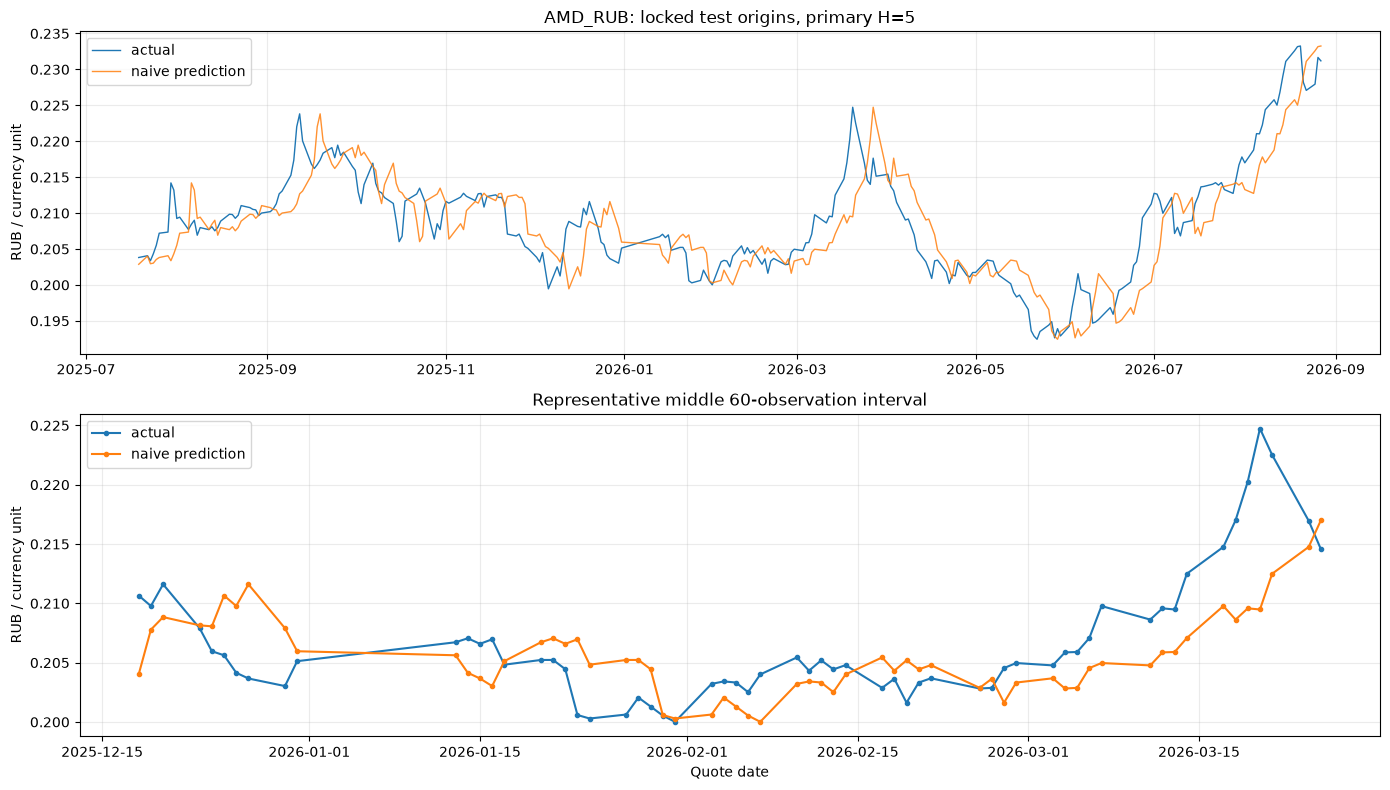

**AMD_RUB.** Для primary `H=5` Naive переносит rate из origin T на target T+5. Zoom выбран детерминированно из середины допустимых test origins, без поиска наиболее удачного интервала.

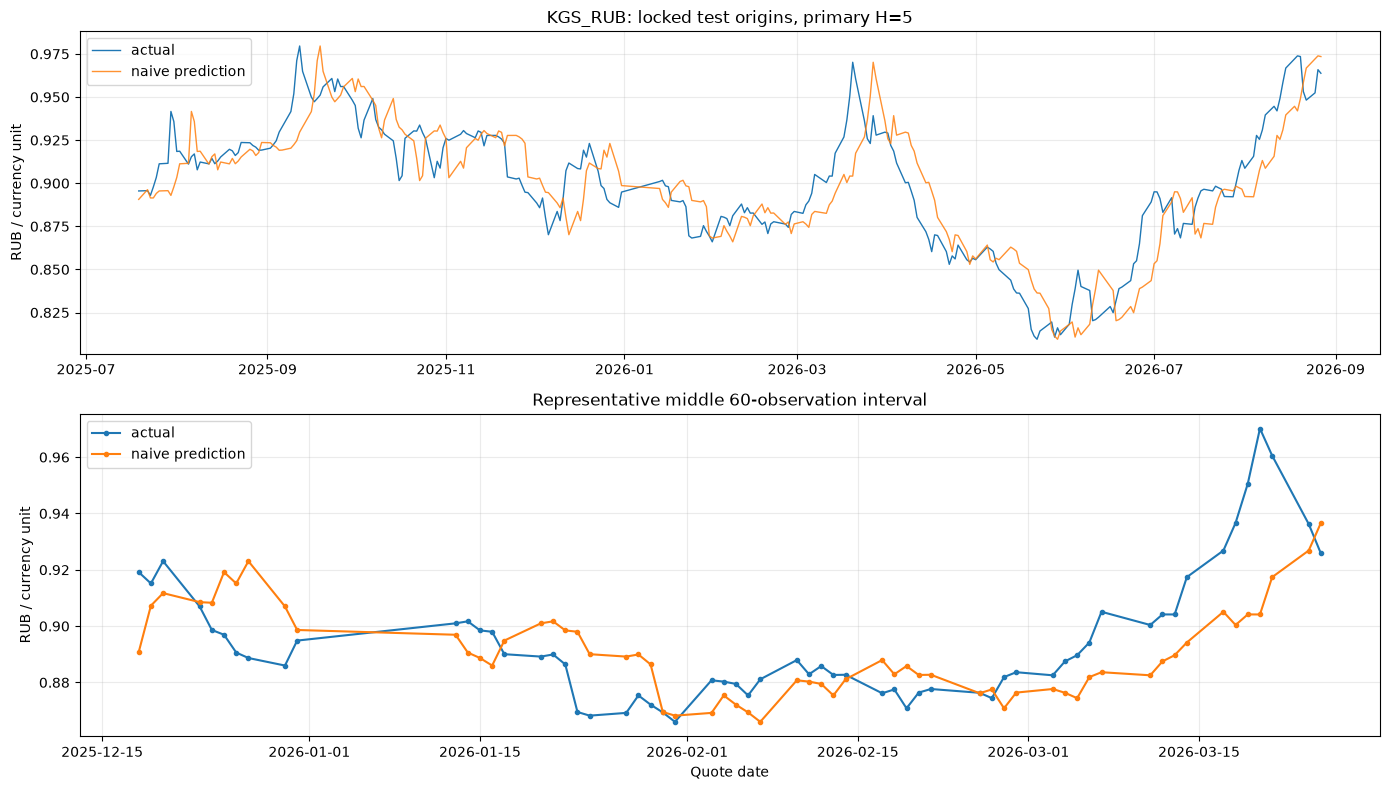

**KGS_RUB.** Для primary `H=5` Naive переносит rate из origin T на target T+5. Zoom выбран детерминированно из середины допустимых test origins, без поиска наиболее удачного интервала.

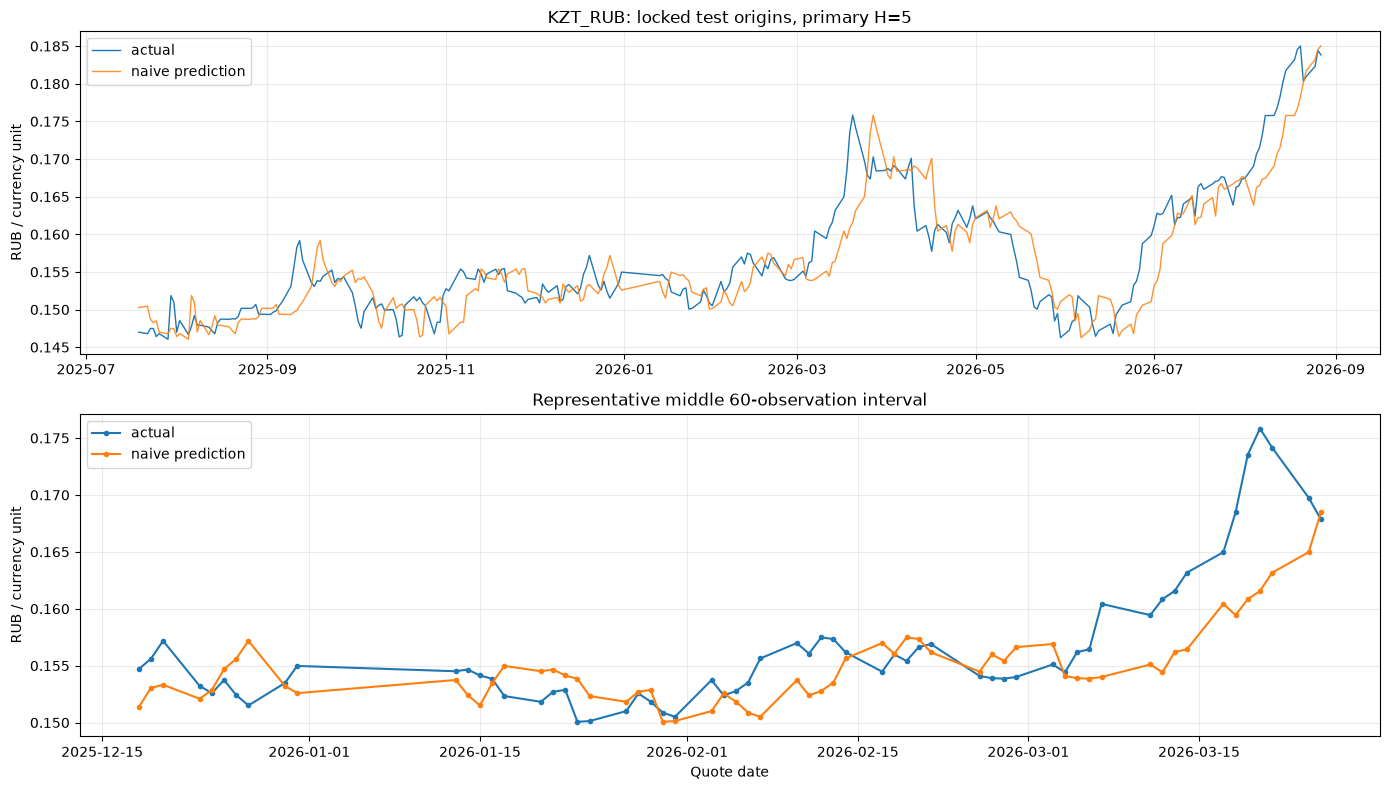

**KZT_RUB.** Для primary `H=5` Naive переносит rate из origin T на target T+5. Zoom выбран детерминированно из середины допустимых test origins, без поиска наиболее удачного интервала.

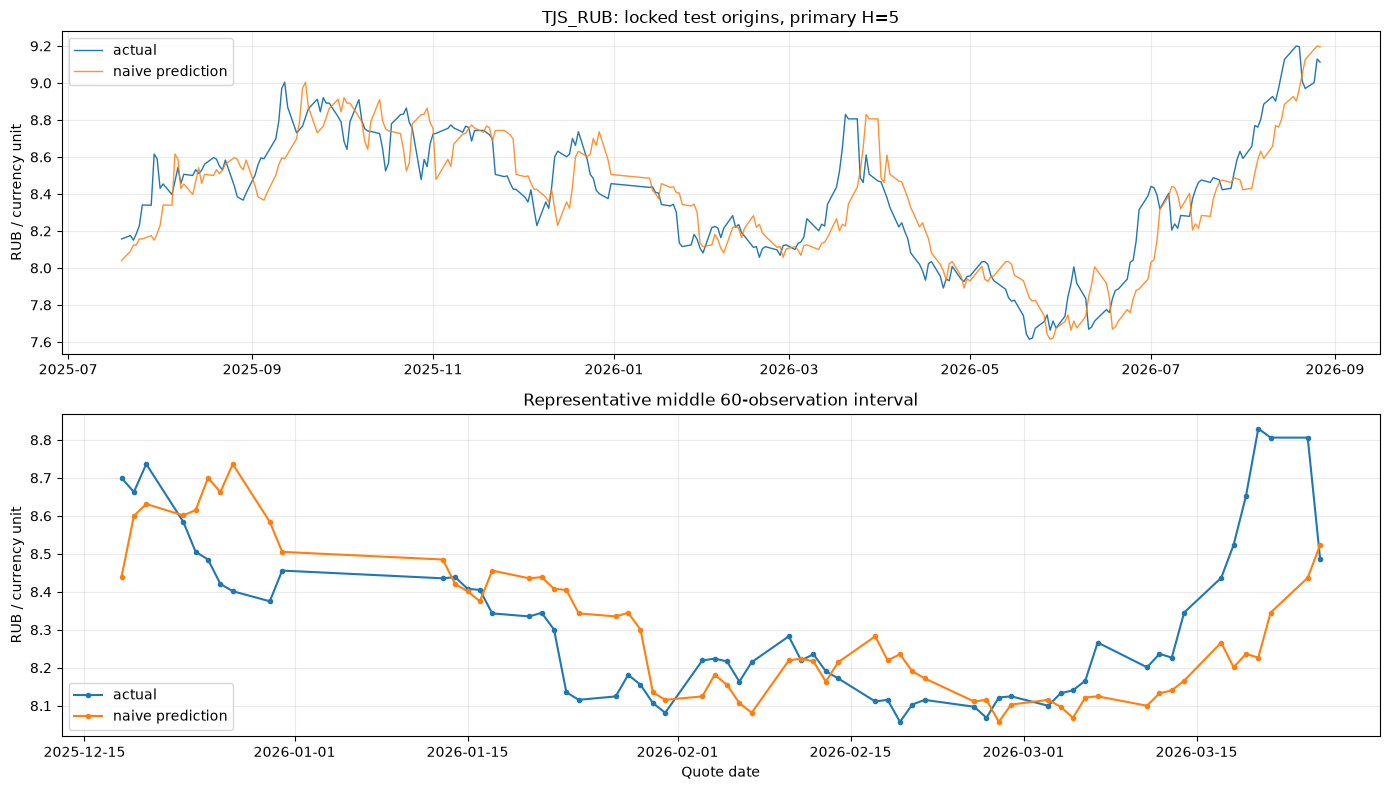

**TJS_RUB.** Для primary `H=5` Naive переносит rate из origin T на target T+5. Zoom выбран детерминированно из середины допустимых test origins, без поиска наиболее удачного интервала.

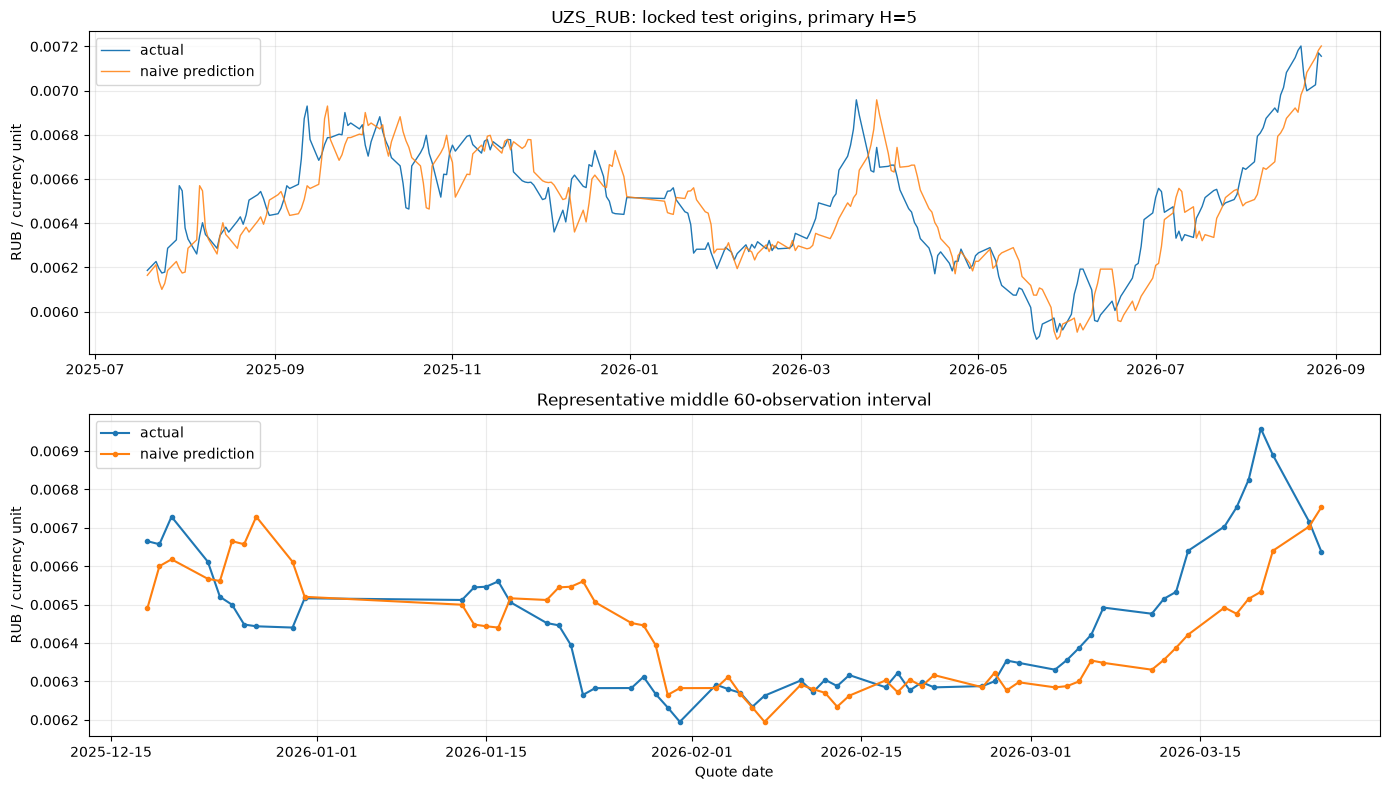

**UZS_RUB.** Для primary `H=5` Naive переносит rate из origin T на target T+5. Zoom выбран детерминированно из середины допустимых test origins, без поиска наиболее удачного интервала.

# STAGE 3 — NAIVE BASELINE: PASS

,corridor,model,horizon,is_primary_horizon,MAE,RMSE,directional_accuracy,normalized_MAE,Path_MAE_H,Future_Best_MAE_H,Regret_MAE_H,n_forecasts
0,AMD_RUB,NAIVE,1,False,0.001335,0.001765,0.000000,0.006380,NaN,NaN,NaN,275
1,AMD_RUB,NAIVE,3,False,0.002689,0.003413,0.000000,0.012818,NaN,NaN,NaN,275
2,AMD_RUB,NAIVE,5,True,0.003491,0.004413,0.000000,0.016625,0.002538,0.002492,0.010045,275
3,AMD_RUB,NAIVE,10,False,0.004907,0.006205,0.000000,0.023284,0.003451,0.003455,0.015124,275
4,KGS_RUB,NAIVE,1,False,0.005722,0.007620,0.000000,0.006353,NaN,NaN,NaN,275
5,KGS_RUB,NAIVE,3,False,0.011664,0.014826,0.000000,0.012939,NaN,NaN,NaN,275
6,KGS_RUB,NAIVE,5,True,0.015246,0.019270,0.000000,0.016918,0.011020,0.011122,0.010534,275
7,KGS_RUB,NAIVE,10,False,0.021649,0.027256,0.000000,0.024018,0.015094,0.015759,0.016133,275
8,KZT_RUB,NAIVE,1,False,0.001242,0.001653,0.000000,0.007901,NaN,NaN,NaN,275
9,KZT_RUB,NAIVE,3,False,0.002288,0.002968,0.000000,0.014489,NaN,NaN,NaN,275


Results: reports/naive_results.csv
Predictions: reports/naive_predictions.csv
Path metrics: reports/naive_path_results.csv
Future best: reports/naive_future_best_predictions.csv
Wide results: reports/naive_results_wide.csv
ARIMA models trained: 0


In [13]:
from src.naive_baseline import run_stage3

stage3_results = run_stage3(ROOT, stage2_results['splits'])

# STAGE 4 — MULTI-STEP ARIMA ON RAW RATE

Отдельные ARIMA для каждого corridor, explicit expanding-window refit, validation-only selection с primary H=5 и locked-test full paths T+1…T+10. На этом этапе не строятся ARIMA на log returns, ARIMAX или good-day classifier.

Реализация находится в `src/arima_rate_multistep.py`; результаты, diagnostics, leakage audit и графики сохраняются в output следующей ячейки.

# STAGE 4 — MULTI-STEP ARIMA ON RAW RATE

`rate` = RUB за единицу валюты получателя; меньший rate выгоднее. Каждый corridor моделируется отдельно. Полный path содержит T+1…T+10 quote observations; primary horizon — H=5.

## Validation grid и honest expanding-window refit

Controlled grid: `p=[0, 1, 2, 3, 5]`, `q=[0, 1, 2, 3, 5]`; `d` взят из Stage 2. Для каждого origin выполняется explicit refit на history `date<=T`. Используется statsmodels ARIMA с `hannan_rissanen` estimator. Известное техническое сообщение о внутреннем differencing этого estimator подавлено; все остальные warnings сохраняются.

Validation cache reused: `True`.

...

,corridor,horizon,endpoint_better_than_naive,path_better_than_naive,future_best_better_than_naive,regret_better_than_naive,endpoint_vs_future_best_disagree
0,AMD_RUB,5,False,False,False,False,False
1,AMD_RUB,10,False,False,False,False,False
2,KGS_RUB,5,False,False,False,False,False
3,KGS_RUB,10,False,False,False,False,False
4,KZT_RUB,5,True,True,True,True,False
5,KZT_RUB,10,False,False,True,True,True
6,TJS_RUB,5,False,False,False,False,False
7,TJS_RUB,10,False,False,False,False,False
8,UZS_RUB,5,False,False,False,False,False
9,UZS_RUB,10,False,False,False,False,False


## Prediction interval width by horizon

,corridor,forecast_step,mean_interval_width
0,AMD_RUB,1,0.008981
1,AMD_RUB,2,0.012701
2,AMD_RUB,3,0.015555
3,AMD_RUB,4,0.017962
4,AMD_RUB,5,0.020082
5,AMD_RUB,6,0.021999
6,AMD_RUB,7,0.023761
7,AMD_RUB,8,0.025402
8,AMD_RUB,9,0.026943
9,AMD_RUB,10,0.028400


Ширина интервала сравнивается между steps 1 и 10; рост означает увеличение model-implied uncertainty на дальнем quote-observation horizon.

,corridor,width_step_1,width_step_10,width_10_to_1_ratio,width_increased
0,AMD_RUB,0.008981,0.028400,3.162278,True
1,KGS_RUB,0.049032,0.155054,3.162278,True
2,KZT_RUB,0.008227,0.026262,3.192149,True
3,TJS_RUB,0.437376,1.383106,3.162278,True
4,UZS_RUB,0.000364,0.001150,3.162278,True


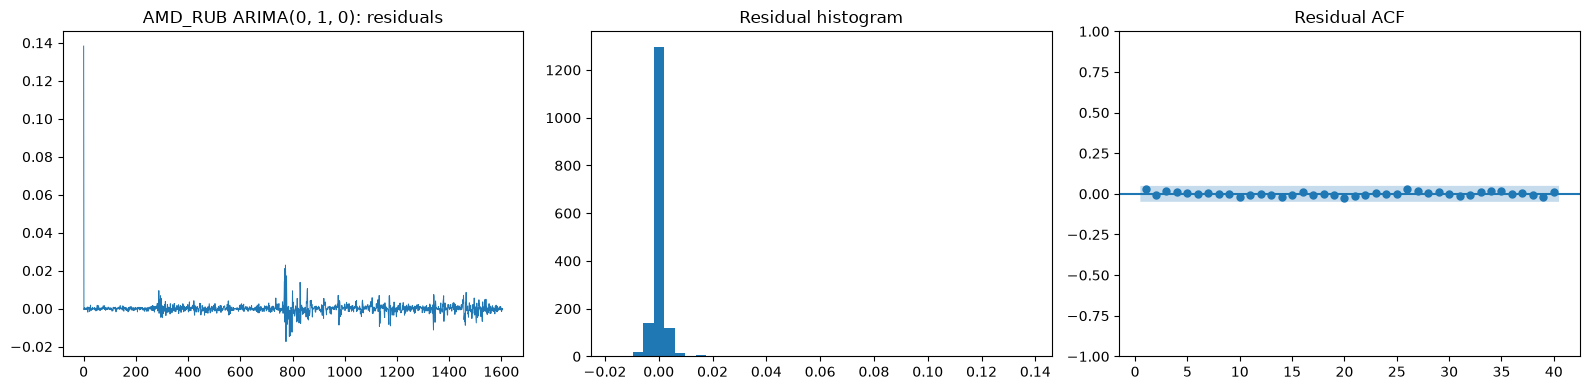

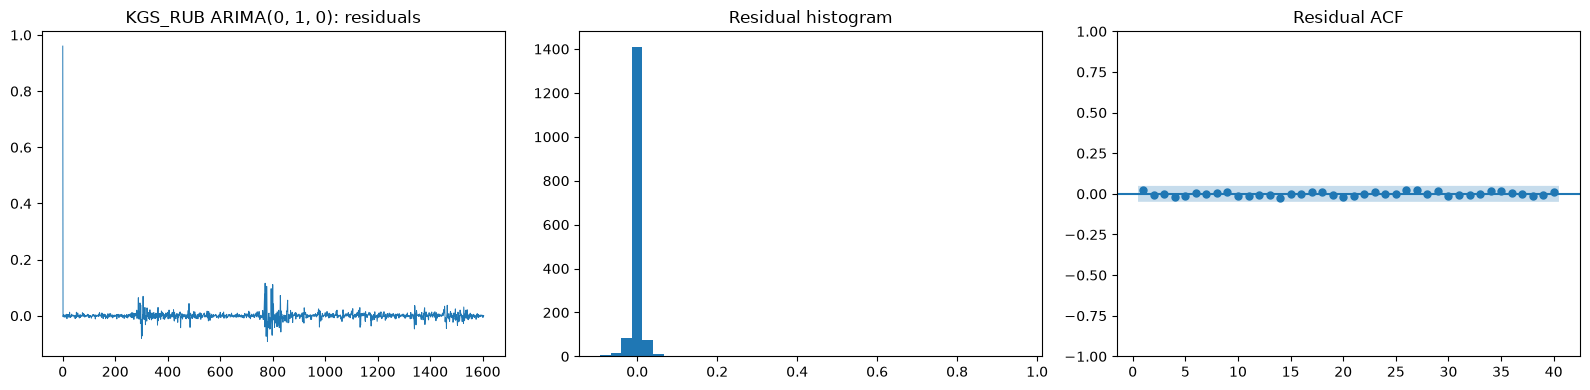

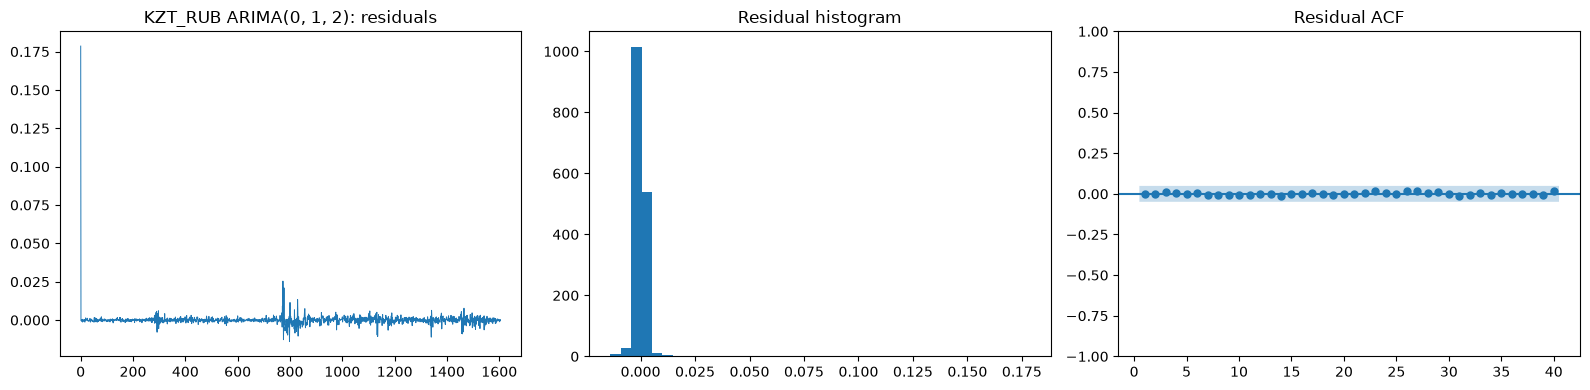

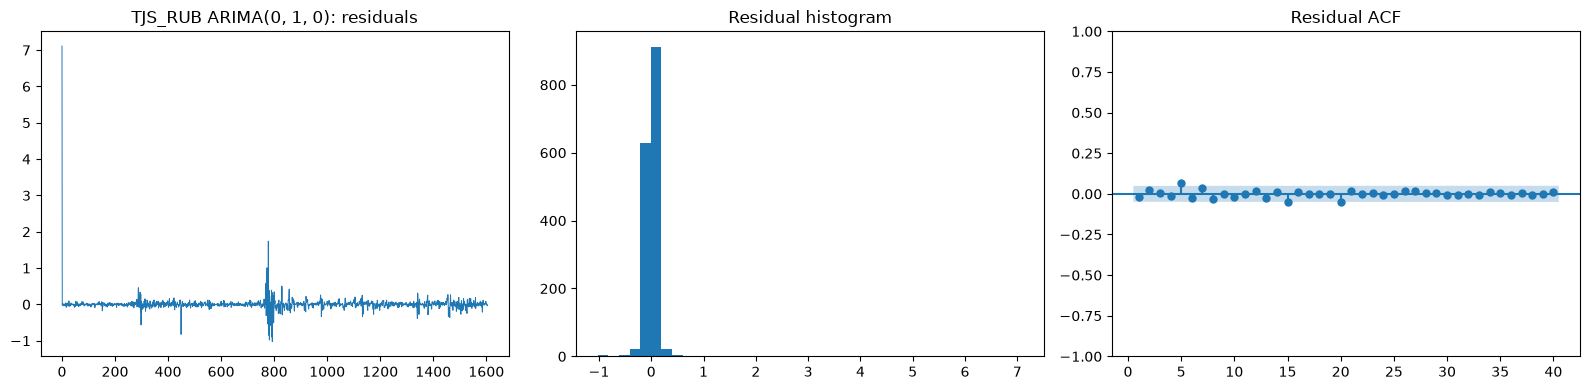

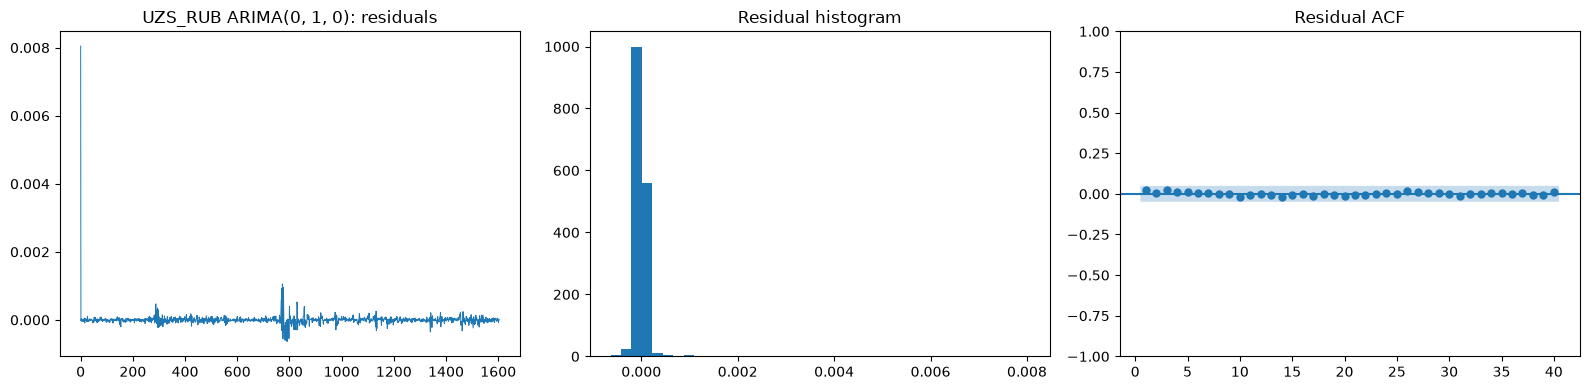

## Residual diagnostics и Ljung–Box

,corridor,p,d,q,lag,lb_stat,lb_pvalue
0,AMD_RUB,0,1,0,10,3.102796,0.978900
1,AMD_RUB,0,1,0,20,5.273419,0.999582
2,KGS_RUB,0,1,0,10,2.232274,0.994230
3,KGS_RUB,0,1,0,20,4.798092,0.999799
4,KZT_RUB,0,1,2,10,0.543125,0.999990
5,KZT_RUB,0,1,2,20,1.002763,1.000000
6,TJS_RUB,0,1,0,10,14.577132,0.148256
7,TJS_RUB,0,1,0,20,24.619147,0.216392
8,UZS_RUB,0,1,0,10,2.741326,0.986873
9,UZS_RUB,0,1,0,20,4.194208,0.999932


## Representative locked-test forecast paths

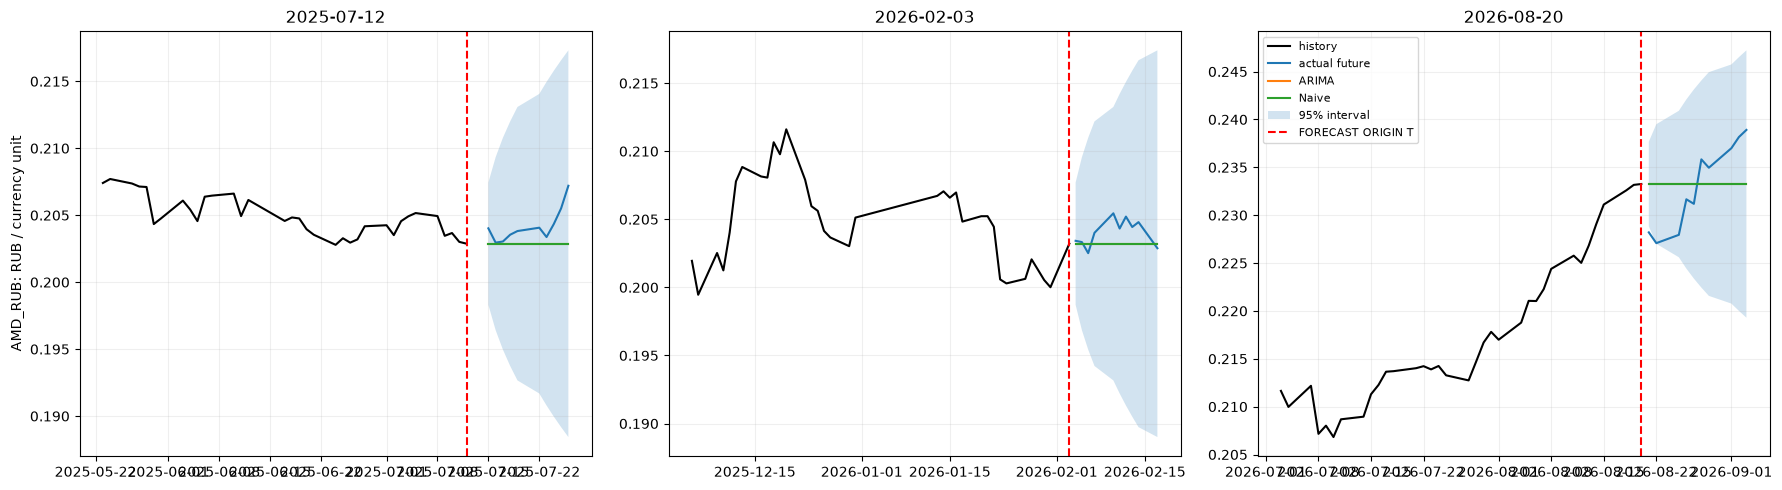

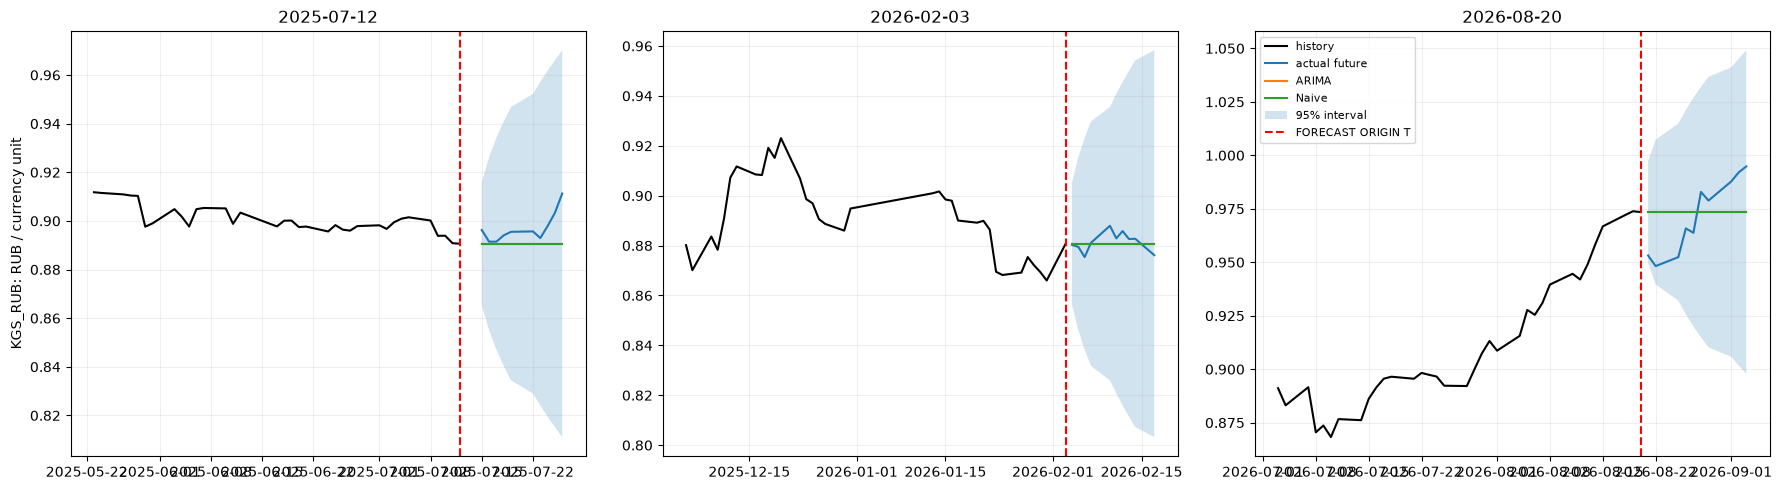

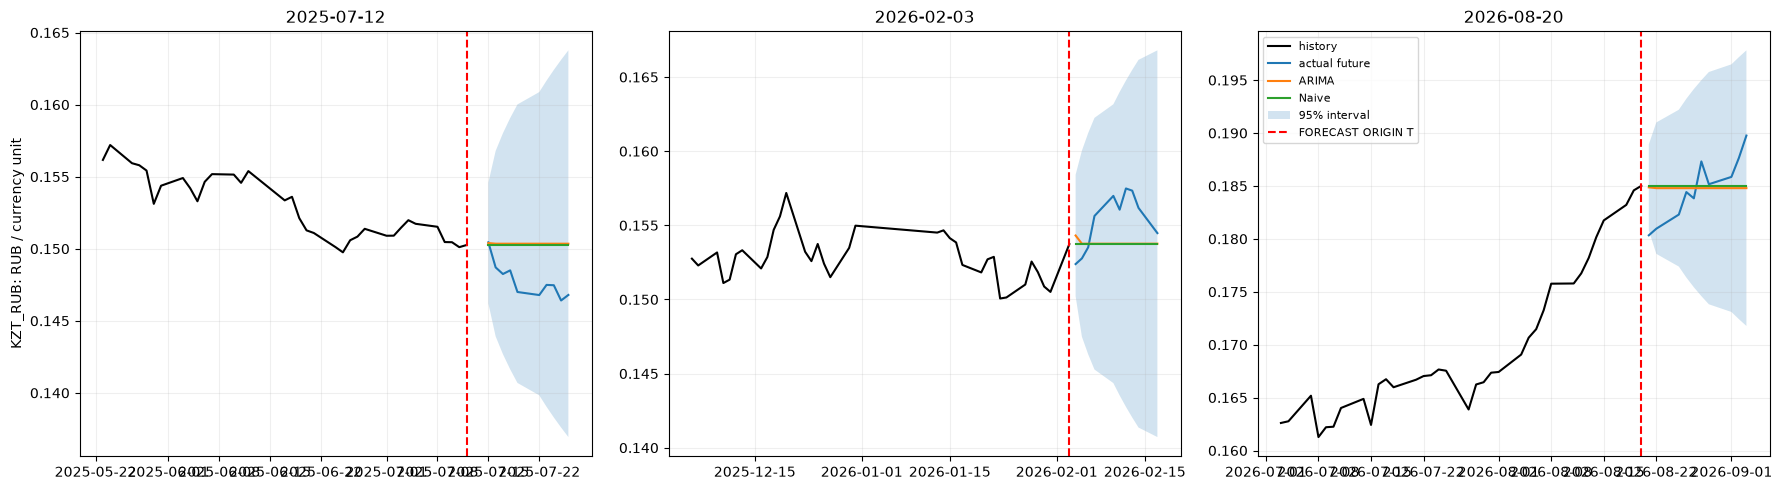

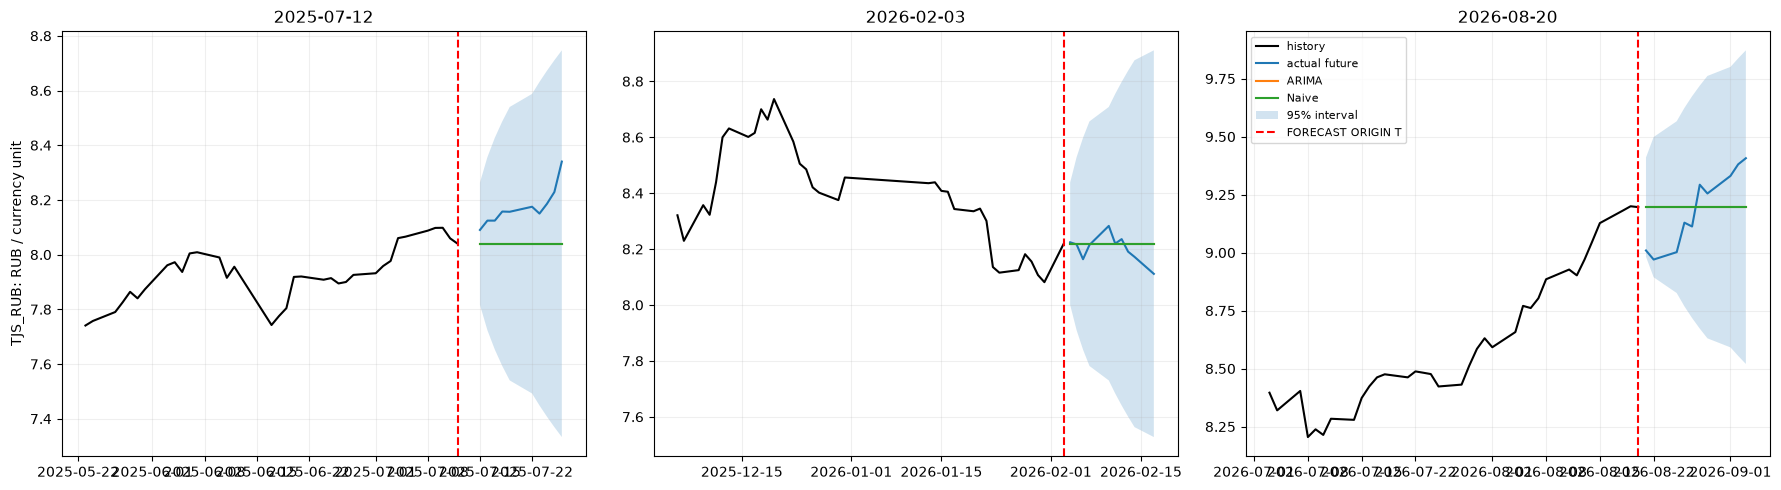

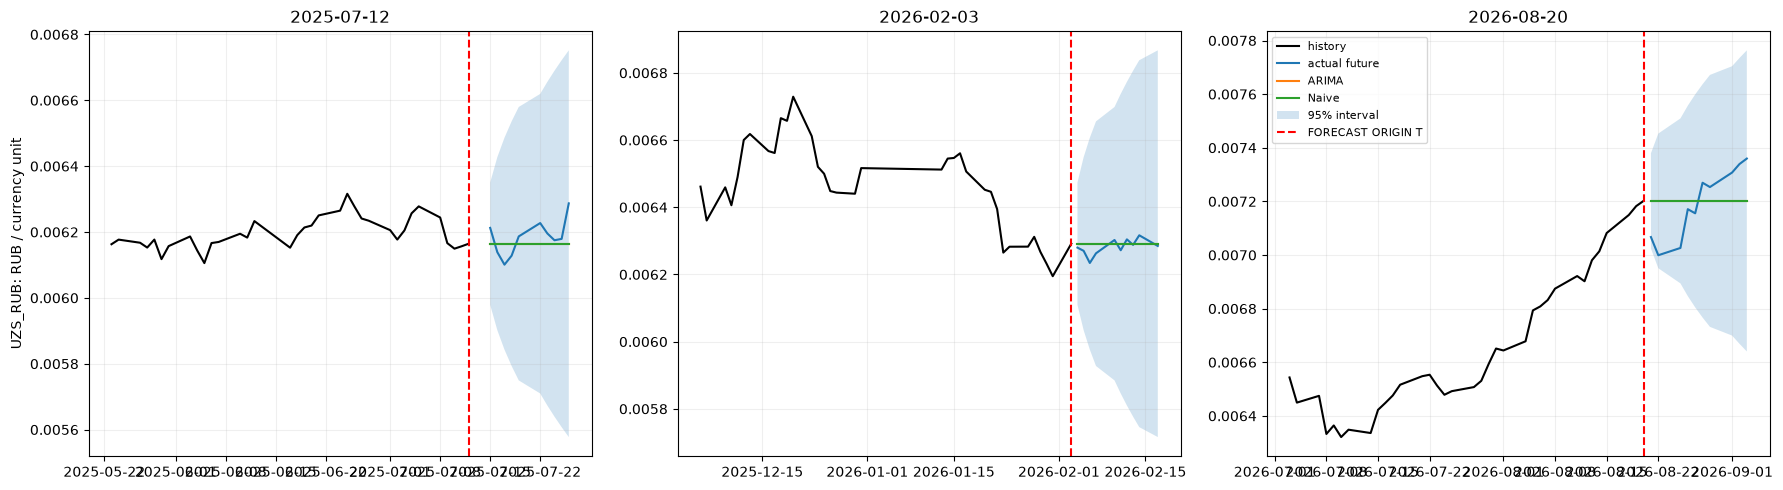

## Endpoint error by horizon: Naive vs ARIMA_RATE

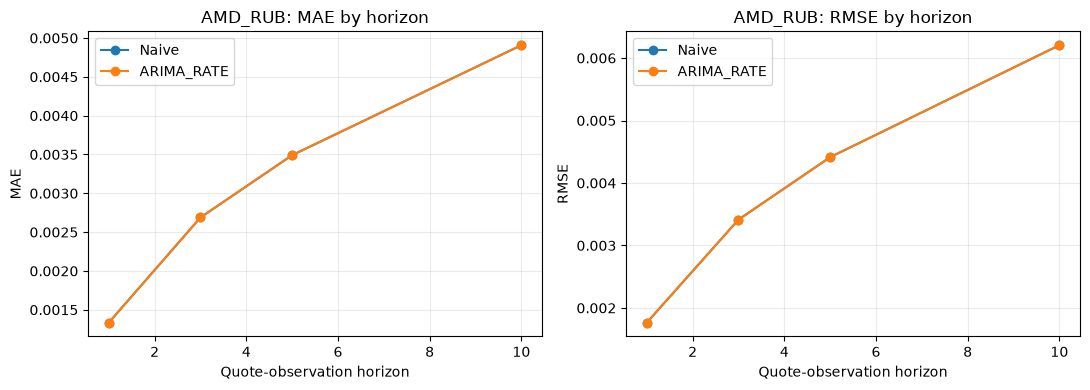

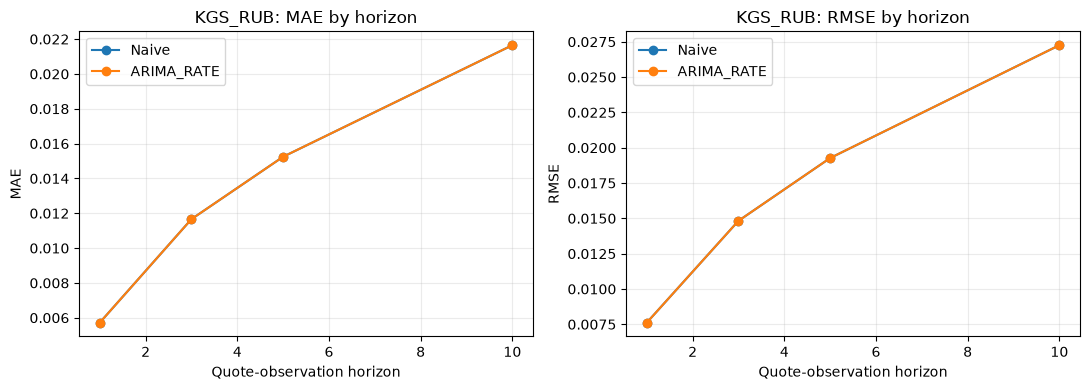

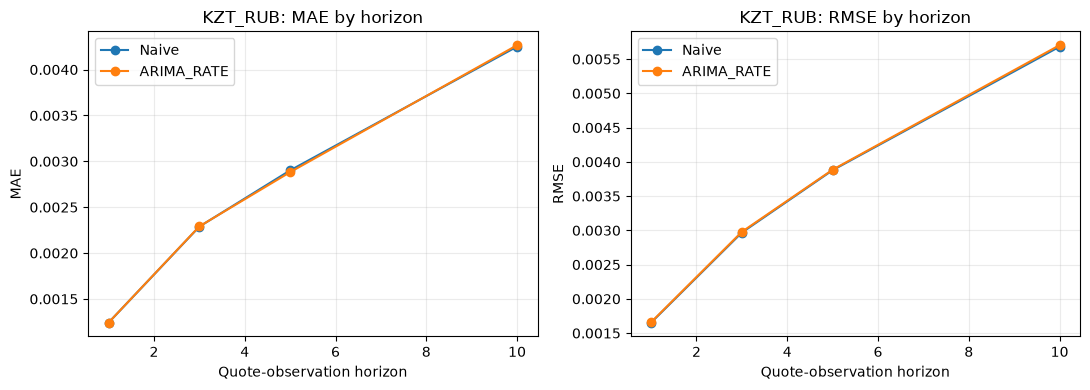

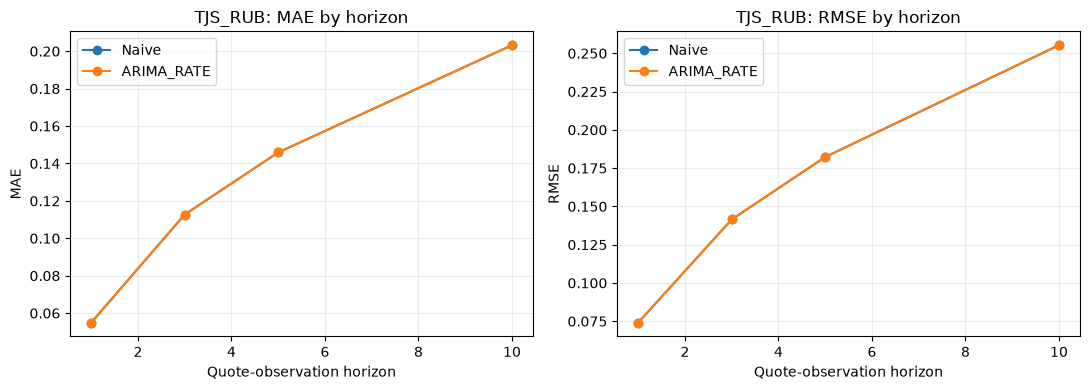

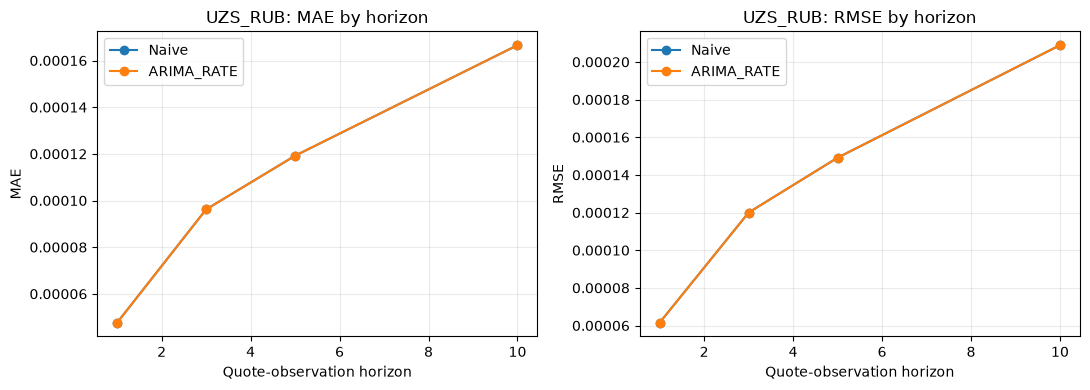

## MULTI-STEP LEAKAGE CHECK: PASS

,check,passed
0,no_random_split,True
1,history_ends_at_origin,True
2,targets_strictly_after_origin,True
3,complete_steps_1_to_10,True
4,d_selected_before_test,True
5,p_q_selected_validation_only,True
6,h5_rule_fixed_before_test,True
7,same_origins_naive_arima,True
8,intervals_model_history_only,True
9,future_best_evaluation_only,True


## Compact summary

,corridor,best_order,test_MAE_H1,test_MAE_H3,test_MAE_H5,test_MAE_H10,test_DA_H5,test_Path_MAE_5,test_Future_Best_MAE_5,MAE_ratio_vs_naive_H5
0,AMD_RUB,"ARIMA(0,1,0)",0.001335,0.002689,0.003491,0.004907,0.000000,0.002538,0.002492,1.000000
1,KGS_RUB,"ARIMA(0,1,0)",0.005722,0.011664,0.015246,0.021649,0.000000,0.011020,0.011122,1.000000
2,KZT_RUB,"ARIMA(0,1,2)",0.001242,0.002291,0.002882,0.004266,0.523636,0.002190,0.002113,0.993455
3,TJS_RUB,"ARIMA(0,1,0)",0.054922,0.112715,0.145904,0.203219,0.000000,0.106032,0.105599,1.000000
4,UZS_RUB,"ARIMA(0,1,0)",0.000048,0.000096,0.000119,0.000167,0.000000,0.000089,0.000088,1.000000


**AMD_RUB: ARIMA(0,1,0).** H=5 MAE `0.0034910545`, Naive MAE `0.0034910545`, improvement `-0.00%`; H=10 ratio `1.000`; Future Best MAE H=5 `0.0024921455`. ARIMA does not improve Naive на H=5 и превосходит его на `0/4` endpoint horizons. Средняя ширина 95% interval к step 10 стала в `3.16` раза больше. Это сравнительный результат, а не утверждение, что будущий курс предсказуем.

...

**KZT_RUB: ARIMA(0,1,2).** H=5 MAE `0.0028823827`, Naive MAE `0.0029013709`, improvement `0.65%`; H=10 ratio `1.004`; Future Best MAE H=5 `0.002112769`. ARIMA improves Naive на H=5 и превосходит его на `1/4` endpoint horizons. Средняя ширина 95% interval к step 10 стала в `3.19` раза больше. Это сравнительный результат, а не утверждение, что будущий курс предсказуем.

**TJS_RUB: ARIMA(0,1,0).** H=5 MAE `0.14590415`, Naive MAE `0.14590415`, improvement `-0.00%`; H=10 ratio `1.000`; Future Best MAE H=5 `0.10559909`. ARIMA does not improve Naive на H=5 и превосходит его на `0/4` endpoint horizons. Средняя ширина 95% interval к step 10 стала в `3.16` раза больше. Это сравнительный результат, а не утверждение, что будущий курс предсказуем.

**UZS_RUB: ARIMA(0,1,0).** H=5 MAE `0.00011918553`, Naive MAE `0.00011918553`, improvement `-0.00%`; H=10 ratio `1.000`; Future Best MAE H=5 `8.7572945e-05`. ARIMA does not improve Naive на H=5 и превосходит его на `0/4` endpoint horizons. Средняя ширина 95% interval к step 10 стала в `3.16` раза больше. Это сравнительный результат, а не утверждение, что будущий курс предсказуем.

# STAGE 4 — MULTI-STEP ARIMA RATE: PASS

PRIMARY HORIZON: H = 5 quote observations
SECONDARY HORIZONS: 1, 3, 10
Best ARIMA per corridor:
corridor   best_order
 AMD_RUB ARIMA(0,1,0)
 KGS_RUB ARIMA(0,1,0)
 KZT_RUB ARIMA(0,1,2)
 TJS_RUB ARIMA(0,1,0)
 UZS_RUB ARIMA(0,1,0)
ARIMA beats Naive on H=5: 1 of 5 corridors
ARIMA beats Naive on H=10: 0 of 5 corridors
Average MAE ratio vs Naive H=5: 0.998691
Average MAE ratio vs Naive H=10: 1.000719
Average Future Best MAE H=5: 0.024282745
Leakage check: PASS
Files created:
reports/arima_rate_multistep_results.csv
reports/arima_rate_test_forecasts.csv


In [14]:
from src.arima_rate_multistep import run_stage4

stage4_results = run_stage4(ROOT)